In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler


Causal Dataset Shape:
(252434, 15)

Columns:
['CustomerID', 'InvoiceNo', 'InvoiceDate', 'Quantity', 'UnitPrice', 'TotalPrice', 'DiscountAmount', 'DiscountRate', 'DiscountTreatment', 'PurchaseOutcome', 'PreviousSpend', 'PreviousQuantity', 'PreviousTransactions', 'AverageUnitPrice', 'RecencyDays']

Missing Values:
CustomerID              0
InvoiceNo               0
InvoiceDate             0
Quantity                0
UnitPrice               0
TotalPrice              0
DiscountAmount          0
DiscountRate            0
DiscountTreatment       0
PurchaseOutcome         0
PreviousSpend           0
PreviousQuantity        0
PreviousTransactions    0
AverageUnitPrice        0
RecencyDays             0
dtype: int64

Duplicate Rows:
0

Treatment Distribution:
DiscountTreatment
0    141473
1    110961
Name: count, dtype: int64

Treatment Percentage:
DiscountTreatment
0    56.04356
1    43.95644
Name: proportion, dtype: float64

Outcome Distribution:
PurchaseOutcome
1    252434
Name: count, dtype

,DiscountTreatment,Customers,Transactions,AverageSpend,AverageQuantity,AverageUnitPrice,AverageRecency
0,0,4192,17946,29.269363,7.174168,5.968992,43.972094
1,1,4109,16720,21.209883,26.571210,1.070349,44.412280


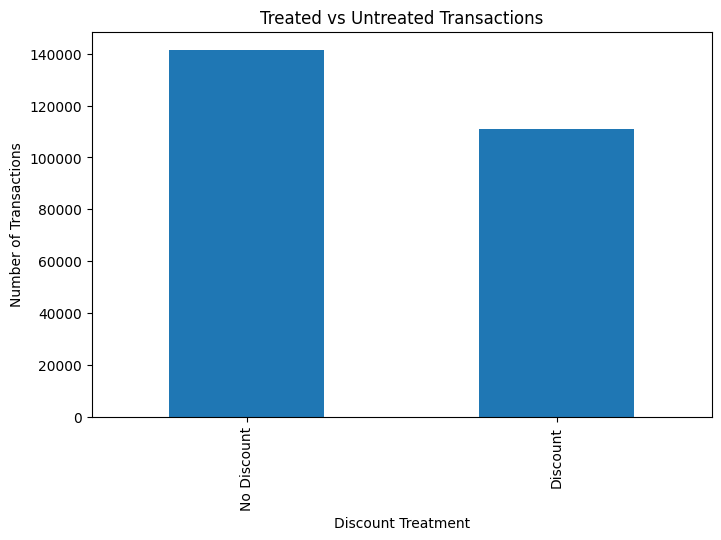

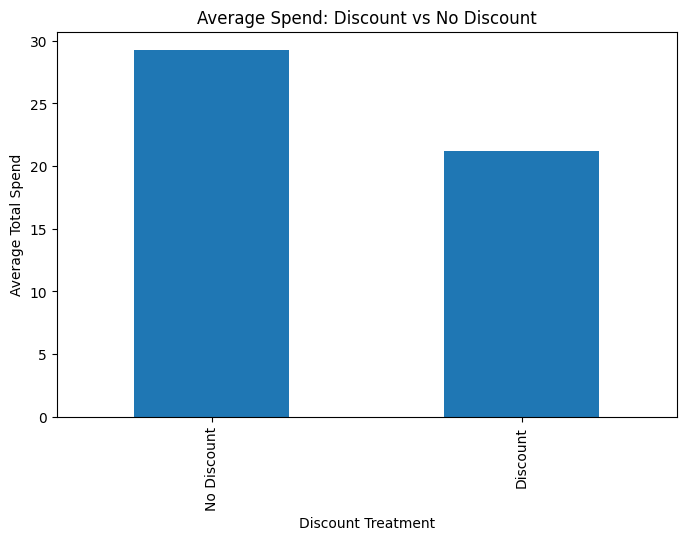

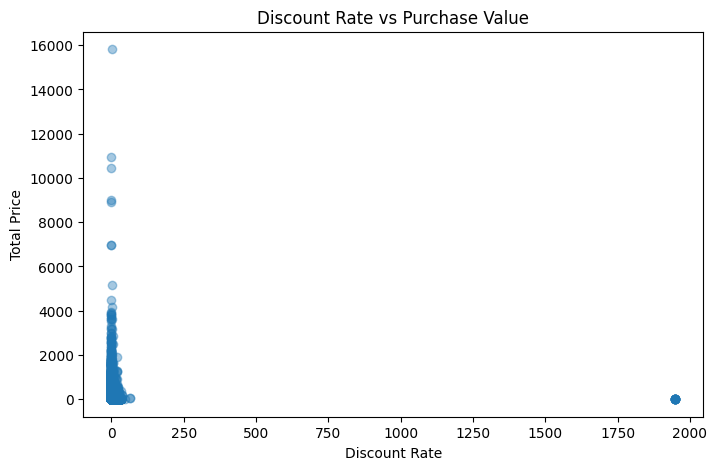


Correlation Matrix:


,DiscountRate,DiscountTreatment,PurchaseOutcome,PreviousSpend,PreviousQuantity,PreviousTransactions,AverageUnitPrice,RecencyDays,Quantity,UnitPrice,TotalPrice
DiscountRate,1.000000,0.058537,NaN,-0.000669,0.004415,-0.002460,-0.000726,0.007343,0.024173,-0.003884,-0.004499
DiscountTreatment,0.058537,1.000000,NaN,0.003760,0.027306,-0.013048,-0.011081,0.003363,0.086626,-0.055118,-0.043711
PurchaseOutcome,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PreviousSpend,-0.000669,0.003760,NaN,1.000000,0.944659,0.700974,0.009053,-0.171410,0.104727,0.010584,0.240213
PreviousQuantity,0.004415,0.027306,NaN,0.944659,1.000000,0.618982,0.003862,-0.151282,0.217111,0.006204,0.243911
PreviousTransactions,-0.002460,-0.013048,NaN,0.700974,0.618982,1.000000,0.006020,-0.255091,0.025126,0.007759,0.075667
AverageUnitPrice,-0.000726,-0.011081,NaN,0.009053,0.003862,0.006020,1.000000,0.015370,0.002251,0.707726,0.350187
RecencyDays,0.007343,0.003363,NaN,-0.171410,-0.151282,-0.255091,0.015370,1.000000,0.016096,0.010594,-0.017266
Quantity,0.024173,0.086626,NaN,0.104727,0.217111,0.025126,0.002251,0.016096,1.000000,-0.006972,0.397292
UnitPrice,-0.003884,-0.055118,NaN,0.010584,0.006204,0.007759,0.707726,0.010594,-0.006972,1.000000,0.482268


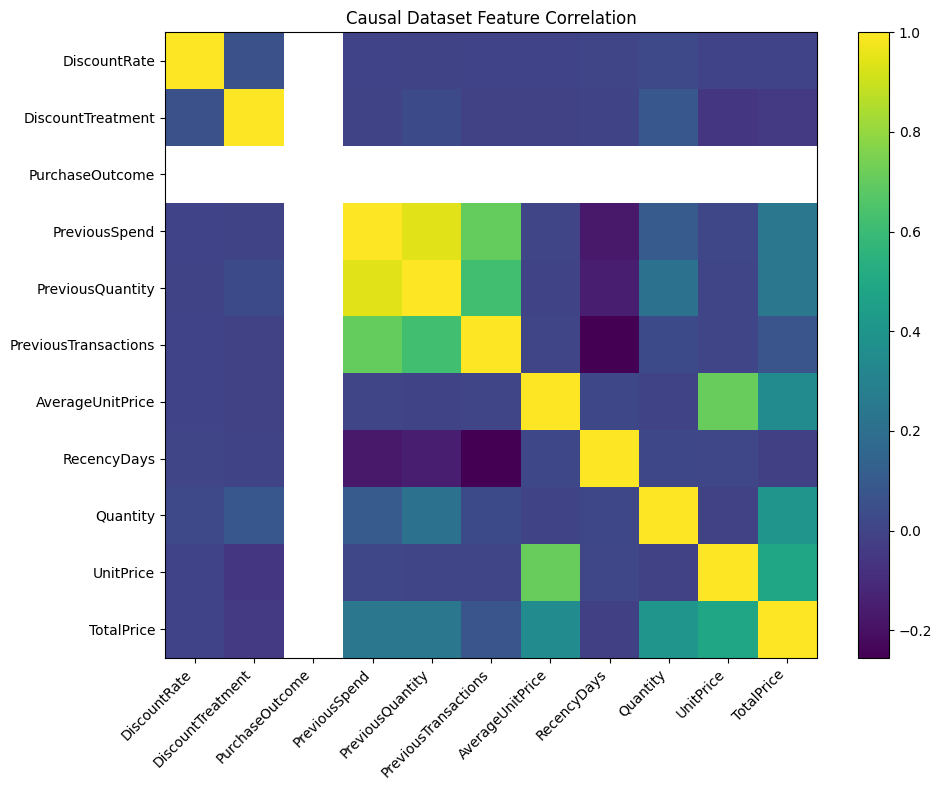


CAUSAL ML DATASET PREPARATION COMPLETED
Rows: 252434
Columns: 15
Treated Transactions: 110961
Untreated Transactions: 141473
Average Spend: 25.73
Average Discount Rate: 0.7564

Saved File:
../data/processed/causal_ml_dataset.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/cleaned_online_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df = df.dropna(
    subset=["CustomerID", "InvoiceNo", "Quantity", "UnitPrice", "InvoiceDate"]
)

df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

df["DiscountAmount"] = np.maximum(
    0,
    df["UnitPrice"].median() - df["UnitPrice"]
)

df["DiscountRate"] = (
    df["DiscountAmount"] /
    df["UnitPrice"].replace(0, np.nan)
)

df["DiscountRate"] = df["DiscountRate"].fillna(0)

df["DiscountTreatment"] = (
    df["DiscountRate"] > 0
).astype(int)

df["PurchaseOutcome"] = (
    df["Quantity"] > 0
).astype(int)

customer_history = df.groupby("CustomerID").agg(
    PreviousSpend=("TotalPrice", "sum"),
    PreviousQuantity=("Quantity", "sum"),
    PreviousTransactions=("InvoiceNo", "nunique"),
    AverageUnitPrice=("UnitPrice", "mean")
).reset_index()

df = df.merge(
    customer_history,
    on="CustomerID",
    how="left"
)

df["CustomerRecency"] = (
    df.groupby("CustomerID")["InvoiceDate"]
    .transform("max")
)

reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

df["RecencyDays"] = (
    reference_date - df["CustomerRecency"]
).dt.days

causal_df = df[
    [
        "CustomerID",
        "InvoiceNo",
        "InvoiceDate",
        "Quantity",
        "UnitPrice",
        "TotalPrice",
        "DiscountAmount",
        "DiscountRate",
        "DiscountTreatment",
        "PurchaseOutcome",
        "PreviousSpend",
        "PreviousQuantity",
        "PreviousTransactions",
        "AverageUnitPrice",
        "RecencyDays"
    ]
].copy()

causal_df = causal_df.replace(
    [np.inf, -np.inf],
    np.nan
)

causal_df = causal_df.dropna()

causal_df = causal_df.drop_duplicates()

print("Causal Dataset Shape:")
print(causal_df.shape)

print("\nColumns:")
print(causal_df.columns.tolist())

print("\nMissing Values:")
print(causal_df.isnull().sum())

print("\nDuplicate Rows:")
print(causal_df.duplicated().sum())

print("\nTreatment Distribution:")
print(
    causal_df["DiscountTreatment"].value_counts()
)

print("\nTreatment Percentage:")
print(
    causal_df["DiscountTreatment"]
    .value_counts(normalize=True)
    .mul(100)
)

print("\nOutcome Distribution:")
print(
    causal_df["PurchaseOutcome"].value_counts()
)

treatment_summary = causal_df.groupby(
    "DiscountTreatment"
).agg(
    Customers=("CustomerID", "nunique"),
    Transactions=("InvoiceNo", "nunique"),
    AverageSpend=("TotalPrice", "mean"),
    AverageQuantity=("Quantity", "mean"),
    AverageUnitPrice=("UnitPrice", "mean"),
    AverageRecency=("RecencyDays", "mean")
).reset_index()

print("\nTreatment vs Outcome Analysis:")
display(treatment_summary)

plt.figure(figsize=(8, 5))

causal_df["DiscountTreatment"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Discount Treatment")
plt.ylabel("Number of Transactions")
plt.title("Treated vs Untreated Transactions")
plt.xticks(
    [0, 1],
    ["No Discount", "Discount"]
)

plt.show()

plt.figure(figsize=(8, 5))

causal_df.groupby(
    "DiscountTreatment"
)["TotalPrice"].mean().plot(
    kind="bar"
)

plt.xlabel("Discount Treatment")
plt.ylabel("Average Total Spend")
plt.title("Average Spend: Discount vs No Discount")
plt.xticks(
    [0, 1],
    ["No Discount", "Discount"]
)

plt.show()

plt.figure(figsize=(8, 5))

plt.scatter(
    causal_df["DiscountRate"],
    causal_df["TotalPrice"],
    alpha=0.4
)

plt.xlabel("Discount Rate")
plt.ylabel("Total Price")
plt.title("Discount Rate vs Purchase Value")

plt.show()

numeric_features = [
    "DiscountRate",
    "DiscountTreatment",
    "PurchaseOutcome",
    "PreviousSpend",
    "PreviousQuantity",
    "PreviousTransactions",
    "AverageUnitPrice",
    "RecencyDays",
    "Quantity",
    "UnitPrice",
    "TotalPrice"
]

correlation = causal_df[
    numeric_features
].corr()

print("\nCorrelation Matrix:")
display(correlation)

plt.figure(figsize=(10, 8))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.colorbar()

plt.title("Causal Dataset Feature Correlation")

plt.tight_layout()

plt.show()

causal_df.to_csv(
    "../data/processed/causal_ml_dataset.csv",
    index=False
)

print("\n========================================")
print("CAUSAL ML DATASET PREPARATION COMPLETED")
print("========================================")
print("Rows:", causal_df.shape[0])
print("Columns:", causal_df.shape[1])
print(
    "Treated Transactions:",
    causal_df["DiscountTreatment"].sum()
)
print(
    "Untreated Transactions:",
    (causal_df["DiscountTreatment"] == 0).sum()
)
print(
    "Average Spend:",
    round(causal_df["TotalPrice"].mean(), 2)
)
print(
    "Average Discount Rate:",
    round(causal_df["DiscountRate"].mean(), 4)
)
print("\nSaved File:")
print("../data/processed/causal_ml_dataset.csv")
print("========================================")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/cleaned_online_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

customer_df = df.groupby("CustomerID").agg(
    TotalSpend=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    AverageOrderValue=("TotalPrice", "mean"),
    AverageUnitPrice=("UnitPrice", "mean")
).reset_index()

latest_date = df["InvoiceDate"].max()
reference_date = latest_date + pd.Timedelta(days=1)

recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()

recency["RecencyDays"] = (
    reference_date - recency["InvoiceDate"]
).dt.days

customer_df = customer_df.merge(
    recency[["CustomerID", "RecencyDays"]],
    on="CustomerID",
    how="left"
)

print(customer_df.shape)
print(customer_df.columns.tolist())

(4312, 7)
['CustomerID', 'TotalSpend', 'TotalQuantity', 'NumberOfTransactions', 'AverageOrderValue', 'AverageUnitPrice', 'RecencyDays']


In [3]:
correlation = customer_df.corr(numeric_only=True)

correlation

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
CustomerID,1.000000,-0.010369,-0.018842,-0.003574,-0.024128,-0.023654,0.001896
TotalSpend,-0.010369,1.000000,0.775738,0.655504,0.096339,0.025067,-0.120763
TotalQuantity,-0.018842,0.775738,1.000000,0.498078,0.090279,-0.006004,-0.084361
NumberOfTransactions,-0.003574,0.655504,0.498078,1.000000,0.015969,-0.010089,-0.248784
AverageOrderValue,-0.024128,0.096339,0.090279,0.015969,1.000000,0.931375,0.039449
AverageUnitPrice,-0.023654,0.025067,-0.006004,-0.010089,0.931375,1.000000,0.042611
RecencyDays,0.001896,-0.120763,-0.084361,-0.248784,0.039449,0.042611,1.000000


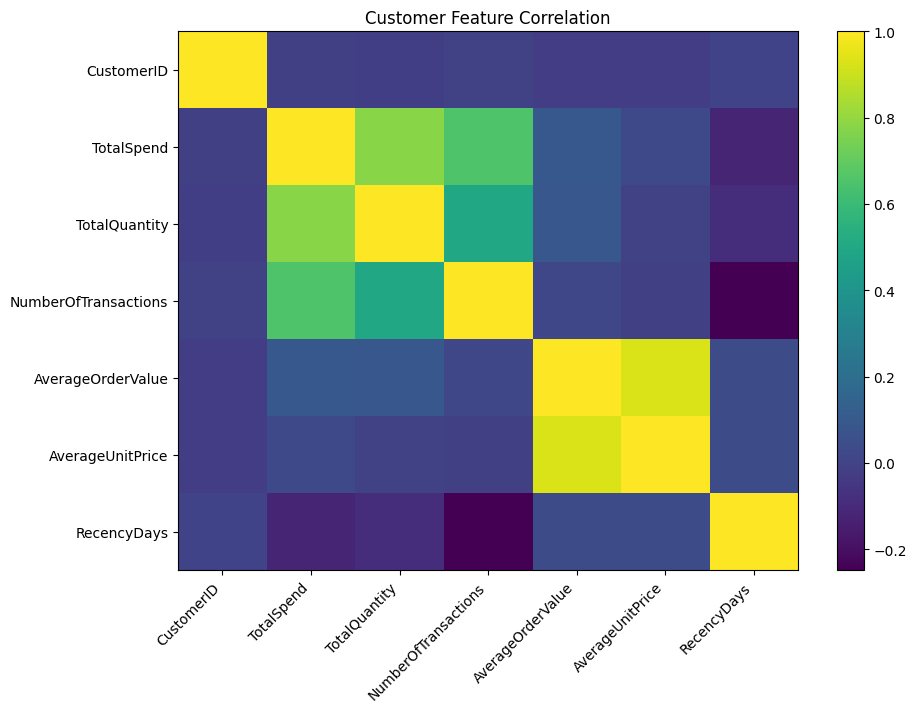

In [4]:
plt.figure(figsize=(10, 7))

plt.imshow(correlation, aspect="auto")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.colorbar()

plt.title("Customer Feature Correlation")

plt.show()

In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/cleaned_online_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [6]:
customer_df = df.groupby("CustomerID").agg(
    TotalSpend=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    AverageOrderValue=("TotalPrice", "mean"),
    AverageUnitPrice=("UnitPrice", "mean")
).reset_index()

(4312, 7)
['CustomerID', 'TotalSpend', 'TotalQuantity', 'NumberOfTransactions', 'AverageOrderValue', 'AverageUnitPrice', 'RecencyDays']
CustomerID              0
TotalSpend              0
TotalQuantity           0
NumberOfTransactions    0
AverageOrderValue       0
AverageUnitPrice        0
RecencyDays             0
dtype: int64


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
count,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,2040.406712,1280.050557,4.455705,37.009327,9.865097,91.171846
std,1701.200176,8911.755977,6457.926351,8.170213,217.715476,203.373443,96.860633
min,12346.000000,2.950000,1.000000,1.000000,1.993684,0.151333,1.000000
25%,13882.500000,307.187500,156.000000,1.000000,11.193531,2.302096,18.000000
50%,15350.500000,701.615000,380.000000,2.000000,17.361560,2.965765,53.000000
75%,16834.250000,1714.932500,992.000000,5.000000,24.839503,3.890407,136.000000
max,18287.000000,349164.350000,220600.000000,205.000000,10953.500000,10953.500000,374.000000


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
0,12346,372.86,70,11,11.298788,6.253333,165
1,12347,1323.32,828,2,18.638310,2.295070,3
2,12348,222.16,373,1,11.108000,0.719500,74
3,12349,2671.14,993,3,26.187647,8.581765,43
4,12351,300.93,261,1,14.330000,2.355238,11


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
4183,18102,349164.35,124216,89,556.880941,3.491930,1
1637,14646,248396.50,170278,78,140.099549,2.402702,10
1269,14156,196549.74,108105,102,74.281837,7.059286,7
1840,14911,152121.22,69709,205,27.320621,5.668200,1
939,13694,131443.19,125893,94,137.349206,1.722497,9
3744,17511,84541.17,55107,31,89.178449,2.502247,3
1951,15061,83284.38,51791,86,142.610240,2.234966,3
3128,16684,80489.21,54555,27,182.515215,2.665011,15
3177,16754,65500.07,63551,29,467.857643,1.681929,8
4065,17949,60117.60,30112,74,691.006897,105.990115,7


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
1840,14911,152121.22,69709,205,27.320621,5.668200,1
3996,17850,51208.87,21052,155,20.491745,3.063581,8
251,12748,22457.90,13109,144,8.873133,3.601881,1
2133,15311,55942.74,32784,121,27.449823,2.880849,1
506,13089,57885.45,29125,109,37.539202,2.656530,4
1606,14606,18482.10,9287,102,4.861152,2.852046,2
1269,14156,196549.74,108105,102,74.281837,7.059286,7
939,13694,131443.19,125893,94,137.349206,1.722497,9
3989,17841,29562.02,14332,91,5.979373,3.022502,1
4183,18102,349164.35,124216,89,556.880941,3.491930,1


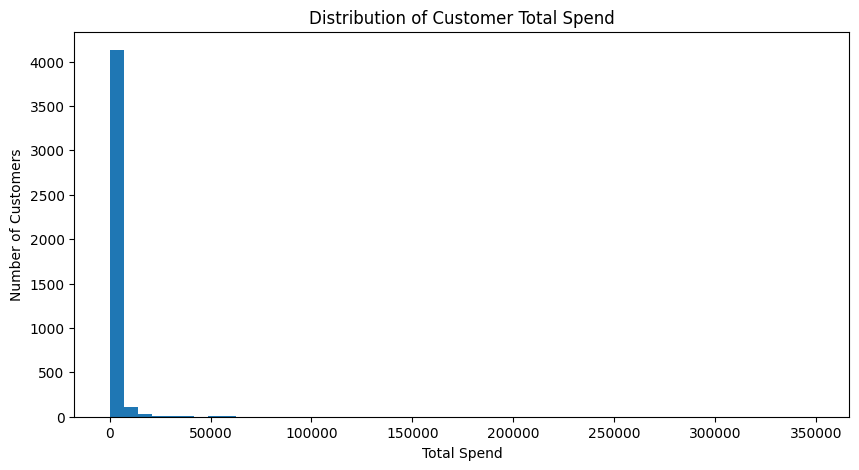

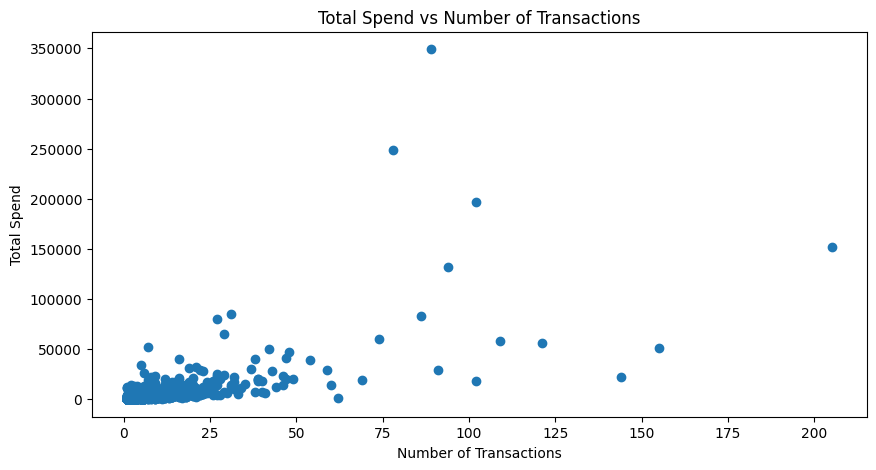

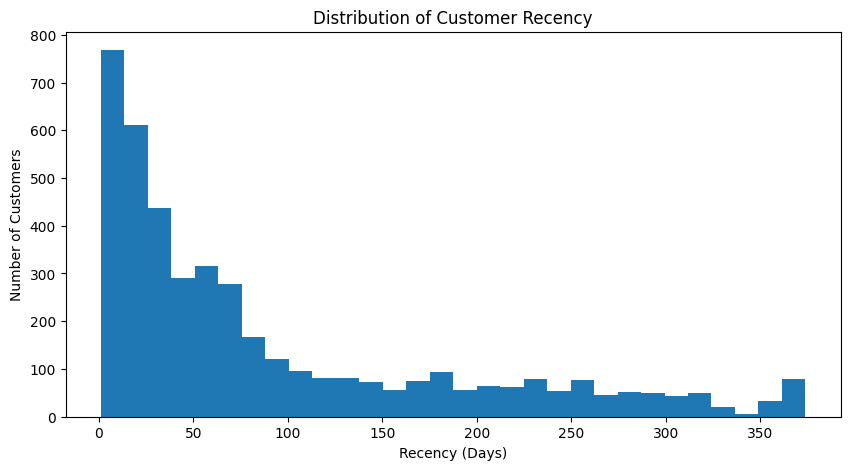

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
CustomerID,1.000000,-0.010369,-0.018842,-0.003574,-0.024128,-0.023654,0.001896
TotalSpend,-0.010369,1.000000,0.775738,0.655504,0.096339,0.025067,-0.120763
TotalQuantity,-0.018842,0.775738,1.000000,0.498078,0.090279,-0.006004,-0.084361
NumberOfTransactions,-0.003574,0.655504,0.498078,1.000000,0.015969,-0.010089,-0.248784
AverageOrderValue,-0.024128,0.096339,0.090279,0.015969,1.000000,0.931375,0.039449
AverageUnitPrice,-0.023654,0.025067,-0.006004,-0.010089,0.931375,1.000000,0.042611
RecencyDays,0.001896,-0.120763,-0.084361,-0.248784,0.039449,0.042611,1.000000


TotalSpend              1.000000
TotalQuantity           0.775738
NumberOfTransactions    0.655504
AverageOrderValue       0.096339
AverageUnitPrice        0.025067
CustomerID             -0.010369
RecencyDays            -0.120763
Name: TotalSpend, dtype: float64

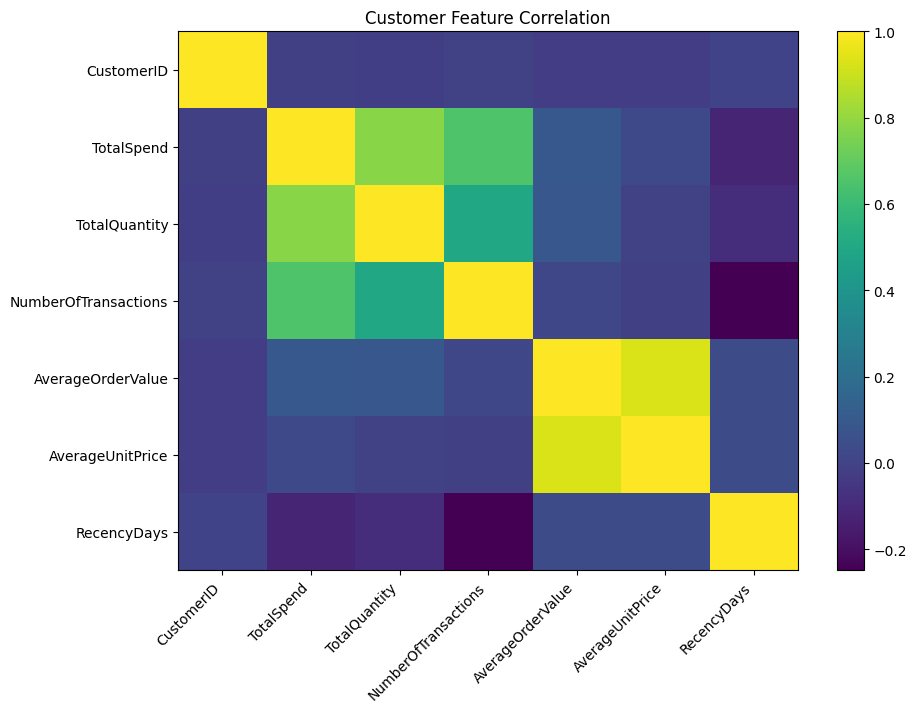

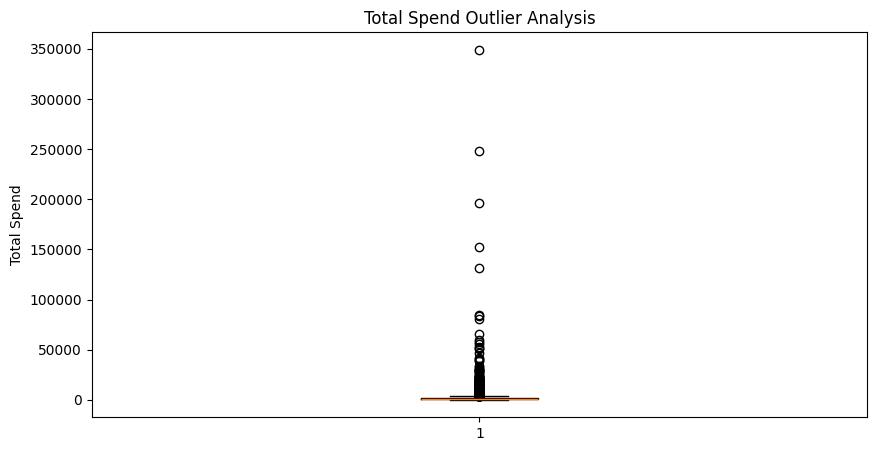

SpendSegment
Low       1438
Medium    1437
High      1437
Name: count, dtype: int64

,count,mean,median,min,max
SpendSegment,,,,,
Low,1438,219.598742,218.405,2.95,399.95
Medium,1437,743.070078,701.620,400.06,1266.77
High,1437,5159.818407,2485.460,1269.05,349164.35


(4312, 8)
['CustomerID', 'TotalSpend', 'TotalQuantity', 'NumberOfTransactions', 'AverageOrderValue', 'AverageUnitPrice', 'RecencyDays', 'SpendSegment']
EDA completed successfully!


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/cleaned_online_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

customer_df = df.groupby("CustomerID").agg(
    TotalSpend=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    AverageOrderValue=("TotalPrice", "mean"),
    AverageUnitPrice=("UnitPrice", "mean")
).reset_index()

latest_date = df["InvoiceDate"].max()
reference_date = latest_date + pd.Timedelta(days=1)

recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()

recency["RecencyDays"] = (
    reference_date - recency["InvoiceDate"]
).dt.days

customer_df = customer_df.merge(
    recency[["CustomerID", "RecencyDays"]],
    on="CustomerID",
    how="left"
)

print(customer_df.shape)
print(customer_df.columns.tolist())
print(customer_df.isnull().sum())

display(customer_df.describe())
display(customer_df.head())

top_spenders = customer_df.sort_values(
    "TotalSpend",
    ascending=False
).head(10)

display(top_spenders)

top_frequent = customer_df.sort_values(
    "NumberOfTransactions",
    ascending=False
).head(10)

display(top_frequent)

plt.figure(figsize=(10, 5))
plt.hist(customer_df["TotalSpend"], bins=50)
plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Total Spend")
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(
    customer_df["NumberOfTransactions"],
    customer_df["TotalSpend"]
)
plt.xlabel("Number of Transactions")
plt.ylabel("Total Spend")
plt.title("Total Spend vs Number of Transactions")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(customer_df["RecencyDays"], bins=30)
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Recency")
plt.show()

correlation = customer_df.corr(numeric_only=True)

display(correlation)
display(correlation["TotalSpend"].sort_values(ascending=False))

plt.figure(figsize=(10, 7))
plt.imshow(correlation, aspect="auto")
plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)
plt.colorbar()
plt.title("Customer Feature Correlation")
plt.show()

plt.figure(figsize=(10, 5))
plt.boxplot(customer_df["TotalSpend"])
plt.ylabel("Total Spend")
plt.title("Total Spend Outlier Analysis")
plt.show()

customer_df["SpendSegment"] = pd.qcut(
    customer_df["TotalSpend"],
    q=3,
    labels=["Low", "Medium", "High"]
)

display(customer_df["SpendSegment"].value_counts())

segment_analysis = customer_df.groupby(
    "SpendSegment",
    observed=True
)["TotalSpend"].agg(
    ["count", "mean", "median", "min", "max"]
)

display(segment_analysis)

customer_df.to_csv(
    "../data/processed/customer_features_eda.csv",
    index=False
)

print(customer_df.shape)
print(customer_df.columns.tolist())
print("EDA completed successfully!")

Customer Dataset Shape: (4312, 8)

Customer Features:
['CustomerID', 'TotalSpend', 'TotalQuantity', 'NumberOfTransactions', 'AverageOrderValue', 'AverageUnitPrice', 'RecencyDays', 'SpendSegment']

Missing Values:
CustomerID              0
TotalSpend              0
TotalQuantity           0
NumberOfTransactions    0
AverageOrderValue       0
AverageUnitPrice        0
RecencyDays             0
SpendSegment            0
dtype: int64

Duplicate Rows: 0

Customer Segment Distribution:
SpendSegment
Low       1438
Medium    1437
High      1437
Name: count, dtype: int64

Segment Analysis:


,SpendSegment,CustomerCount,AverageSpend,MedianSpend,AverageQuantity,AverageTransactions,AverageOrderValue,AverageUnitPrice,AverageRecency
0,Low,1438,219.598742,218.405,133.457580,1.312935,22.634237,5.054556,145.206537
1,Medium,1437,743.070078,701.620,439.100209,2.752958,28.046687,5.285201,83.599861
2,High,1437,5159.818407,2485.460,3268.391788,9.303410,60.357059,19.258881,44.671538



Top 10 Customers by Total Spend:


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays,SpendSegment
4183,18102,349164.35,124216,89,556.880941,3.491930,1,High
1637,14646,248396.50,170278,78,140.099549,2.402702,10,High
1269,14156,196549.74,108105,102,74.281837,7.059286,7,High
1840,14911,152121.22,69709,205,27.320621,5.668200,1,High
939,13694,131443.19,125893,94,137.349206,1.722497,9,High
3744,17511,84541.17,55107,31,89.178449,2.502247,3,High
1951,15061,83284.38,51791,86,142.610240,2.234966,3,High
3128,16684,80489.21,54555,27,182.515215,2.665011,15,High
3177,16754,65500.07,63551,29,467.857643,1.681929,8,High
4065,17949,60117.60,30112,74,691.006897,105.990115,7,High



Top 10 Customers by Number of Transactions:


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays,SpendSegment
1840,14911,152121.22,69709,205,27.320621,5.668200,1,High
3996,17850,51208.87,21052,155,20.491745,3.063581,8,High
251,12748,22457.90,13109,144,8.873133,3.601881,1,High
2133,15311,55942.74,32784,121,27.449823,2.880849,1,High
506,13089,57885.45,29125,109,37.539202,2.656530,4,High
1606,14606,18482.10,9287,102,4.861152,2.852046,2,High
1269,14156,196549.74,108105,102,74.281837,7.059286,7,High
939,13694,131443.19,125893,94,137.349206,1.722497,9,High
3989,17841,29562.02,14332,91,5.979373,3.022502,1,High
4183,18102,349164.35,124216,89,556.880941,3.491930,1,High



Average Feature Values by Segment:


,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
SpendSegment,,,,,,
Low,219.598742,133.457580,1.312935,22.634237,5.054556,145.206537
Medium,743.070078,439.100209,2.752958,28.046687,5.285201,83.599861
High,5159.818407,3268.391788,9.303410,60.357059,19.258881,44.671538


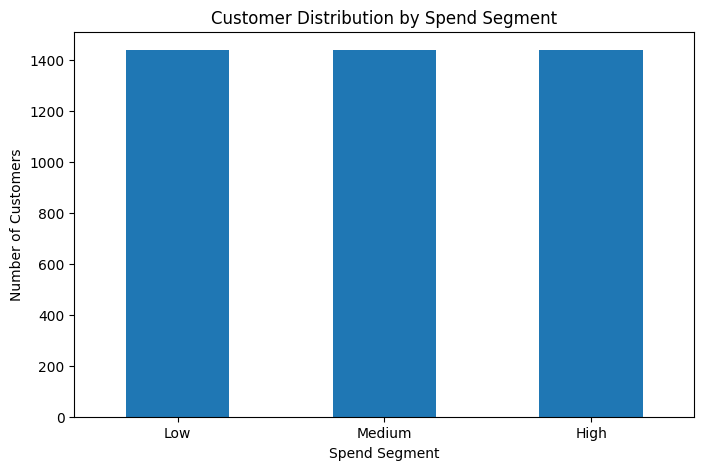

<Figure size 800x500 with 0 Axes>

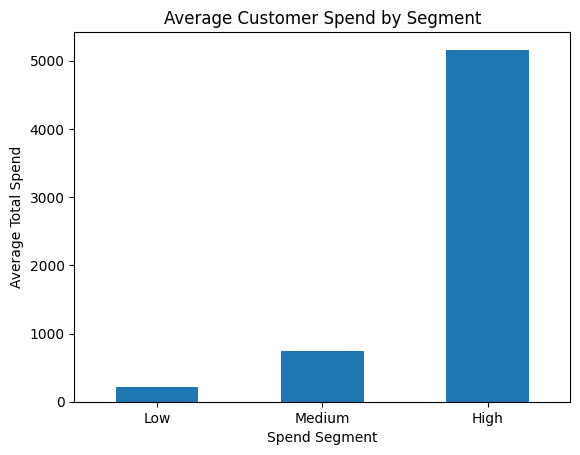

<Figure size 800x500 with 0 Axes>

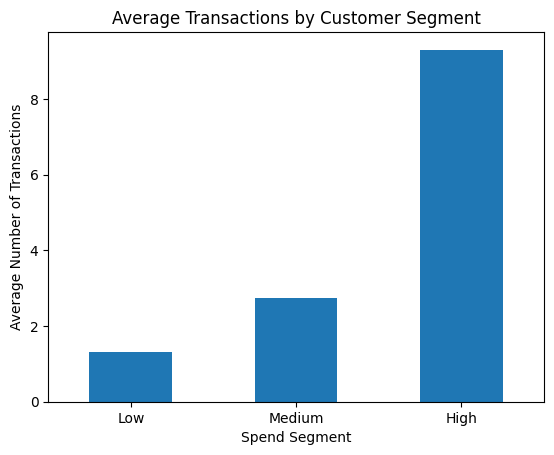

<Figure size 800x500 with 0 Axes>

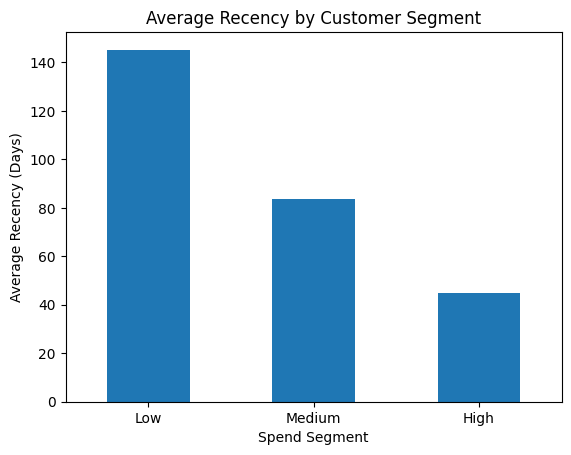

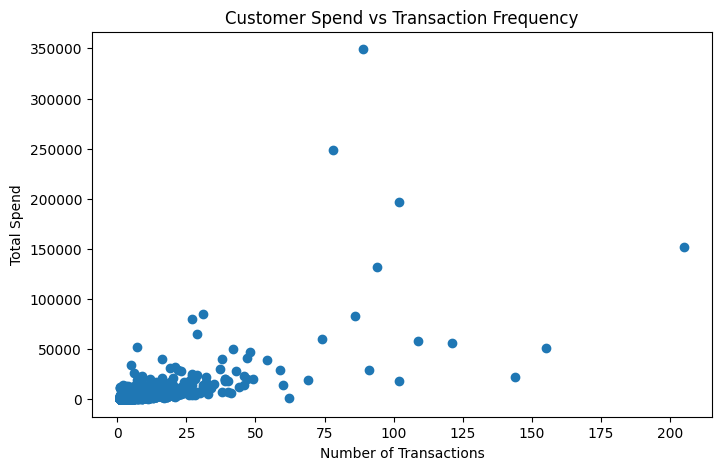


Feature Correlation:


,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
TotalSpend,1.000000,0.775738,0.655504,0.096339,0.025067,-0.120763
TotalQuantity,0.775738,1.000000,0.498078,0.090279,-0.006004,-0.084361
NumberOfTransactions,0.655504,0.498078,1.000000,0.015969,-0.010089,-0.248784
AverageOrderValue,0.096339,0.090279,0.015969,1.000000,0.931375,0.039449
AverageUnitPrice,0.025067,-0.006004,-0.010089,0.931375,1.000000,0.042611
RecencyDays,-0.120763,-0.084361,-0.248784,0.039449,0.042611,1.000000


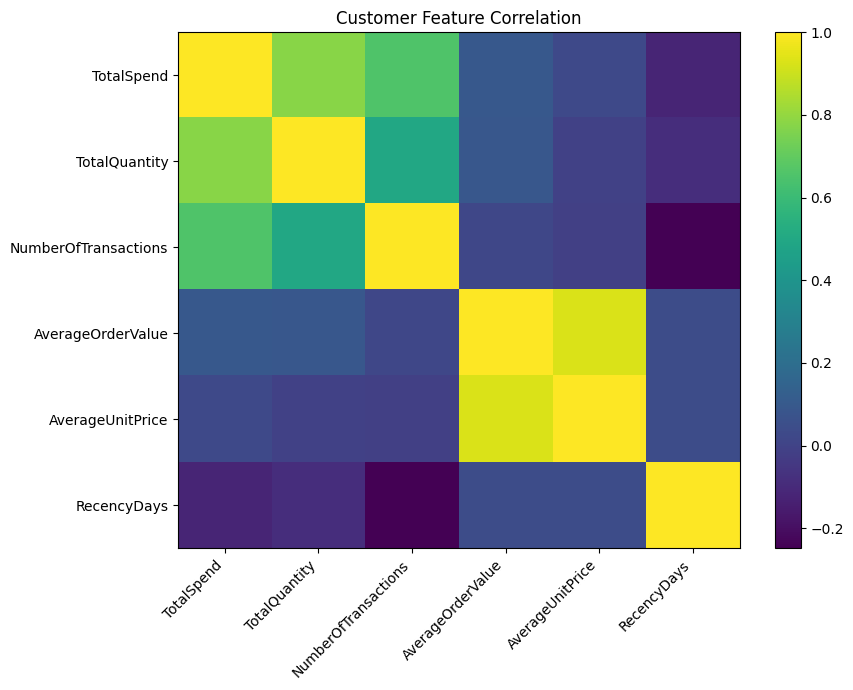


Outlier Analysis:
TotalSpend -> 423 outliers
TotalQuantity -> 412 outliers
NumberOfTransactions -> 285 outliers
AverageOrderValue -> 476 outliers
AverageUnitPrice -> 225 outliers
RecencyDays -> 177 outliers

Final Data Quality Check
Missing Values: 0
Duplicate Rows: 0

CUSTOMER SEGMENTATION COMPLETED
Total Customers: 4312
Total Features: 8
Output File:
../data/processed/customer_features_final.csv


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/cleaned_online_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

customer_df = df.groupby("CustomerID").agg(
    TotalSpend=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    AverageOrderValue=("TotalPrice", "mean"),
    AverageUnitPrice=("UnitPrice", "mean")
).reset_index()

latest_date = df["InvoiceDate"].max()
reference_date = latest_date + pd.Timedelta(days=1)

recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()

recency["RecencyDays"] = (
    reference_date - recency["InvoiceDate"]
).dt.days

customer_df = customer_df.merge(
    recency[["CustomerID", "RecencyDays"]],
    on="CustomerID",
    how="left"
)

customer_df["SpendSegment"] = pd.qcut(
    customer_df["TotalSpend"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

print("Customer Dataset Shape:", customer_df.shape)
print("\nCustomer Features:")
print(customer_df.columns.tolist())

print("\nMissing Values:")
print(customer_df.isnull().sum())

print("\nDuplicate Rows:", customer_df.duplicated().sum())

print("\nCustomer Segment Distribution:")
print(customer_df["SpendSegment"].value_counts())

segment_analysis = customer_df.groupby(
    "SpendSegment",
    observed=True
).agg(
    CustomerCount=("CustomerID", "count"),
    AverageSpend=("TotalSpend", "mean"),
    MedianSpend=("TotalSpend", "median"),
    AverageQuantity=("TotalQuantity", "mean"),
    AverageTransactions=("NumberOfTransactions", "mean"),
    AverageOrderValue=("AverageOrderValue", "mean"),
    AverageUnitPrice=("AverageUnitPrice", "mean"),
    AverageRecency=("RecencyDays", "mean")
).reset_index()

print("\nSegment Analysis:")
display(segment_analysis)

print("\nTop 10 Customers by Total Spend:")
top_spenders = customer_df.sort_values(
    "TotalSpend",
    ascending=False
).head(10)

display(top_spenders)

print("\nTop 10 Customers by Number of Transactions:")
top_frequent = customer_df.sort_values(
    "NumberOfTransactions",
    ascending=False
).head(10)

display(top_frequent)

features = [
    "TotalSpend",
    "TotalQuantity",
    "NumberOfTransactions",
    "AverageOrderValue",
    "AverageUnitPrice",
    "RecencyDays"
]

print("\nAverage Feature Values by Segment:")
display(
    customer_df.groupby(
        "SpendSegment",
        observed=True
    )[features].mean()
)

plt.figure(figsize=(8, 5))

customer_df["SpendSegment"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Spend Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Spend Segment")
plt.xticks(rotation=0)

plt.show()

plt.figure(figsize=(8, 5))

segment_analysis.plot(
    x="SpendSegment",
    y="AverageSpend",
    kind="bar",
    legend=False
)

plt.xlabel("Spend Segment")
plt.ylabel("Average Total Spend")
plt.title("Average Customer Spend by Segment")
plt.xticks(rotation=0)

plt.show()

plt.figure(figsize=(8, 5))

segment_analysis.plot(
    x="SpendSegment",
    y="AverageTransactions",
    kind="bar",
    legend=False
)

plt.xlabel("Spend Segment")
plt.ylabel("Average Number of Transactions")
plt.title("Average Transactions by Customer Segment")
plt.xticks(rotation=0)

plt.show()

plt.figure(figsize=(8, 5))

segment_analysis.plot(
    x="SpendSegment",
    y="AverageRecency",
    kind="bar",
    legend=False
)

plt.xlabel("Spend Segment")
plt.ylabel("Average Recency (Days)")
plt.title("Average Recency by Customer Segment")
plt.xticks(rotation=0)

plt.show()

plt.figure(figsize=(8, 5))

plt.scatter(
    customer_df["NumberOfTransactions"],
    customer_df["TotalSpend"]
)

plt.xlabel("Number of Transactions")
plt.ylabel("Total Spend")
plt.title("Customer Spend vs Transaction Frequency")

plt.show()

correlation = customer_df[features].corr()

print("\nFeature Correlation:")
display(correlation)

plt.figure(figsize=(9, 7))

plt.imshow(correlation, aspect="auto")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.colorbar()

plt.title("Customer Feature Correlation")

plt.tight_layout()

plt.show()

print("\nOutlier Analysis:")

for column in features:

    Q1 = customer_df[column].quantile(0.25)
    Q3 = customer_df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = customer_df[
        (customer_df[column] < lower_bound) |
        (customer_df[column] > upper_bound)
    ]

    print(
        column,
        "->",
        len(outliers),
        "outliers"
    )

print("\nFinal Data Quality Check")

print("Missing Values:", customer_df.isnull().sum().sum())
print("Duplicate Rows:", customer_df.duplicated().sum())

customer_df.to_csv(
    "../data/processed/customer_features_final.csv",
    index=False
)

print("\n===================================")
print("CUSTOMER SEGMENTATION COMPLETED")
print("===================================")
print("Total Customers:", customer_df["CustomerID"].nunique())
print("Total Features:", len(customer_df.columns))
print("Output File:")
print("../data/processed/customer_features_final.csv")
print("===================================")

(4312, 7)
['CustomerID', 'TotalSpend', 'TotalQuantity', 'NumberOfTransactions', 'AverageOrderValue', 'AverageUnitPrice', 'RecencyDays']
CustomerID              0
TotalSpend              0
TotalQuantity           0
NumberOfTransactions    0
AverageOrderValue       0
AverageUnitPrice        0
RecencyDays             0
dtype: int64


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
count,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,2040.406712,1280.050557,4.455705,37.009327,9.865097,91.171846
std,1701.200176,8911.755977,6457.926351,8.170213,217.715476,203.373443,96.860633
min,12346.000000,2.950000,1.000000,1.000000,1.993684,0.151333,1.000000
25%,13882.500000,307.187500,156.000000,1.000000,11.193531,2.302096,18.000000
50%,15350.500000,701.615000,380.000000,2.000000,17.361560,2.965765,53.000000
75%,16834.250000,1714.932500,992.000000,5.000000,24.839503,3.890407,136.000000
max,18287.000000,349164.350000,220600.000000,205.000000,10953.500000,10953.500000,374.000000


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
0,12346,372.86,70,11,11.298788,6.253333,165
1,12347,1323.32,828,2,18.638310,2.295070,3
2,12348,222.16,373,1,11.108000,0.719500,74
3,12349,2671.14,993,3,26.187647,8.581765,43
4,12351,300.93,261,1,14.330000,2.355238,11


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
4183,18102,349164.35,124216,89,556.880941,3.491930,1
1637,14646,248396.50,170278,78,140.099549,2.402702,10
1269,14156,196549.74,108105,102,74.281837,7.059286,7
1840,14911,152121.22,69709,205,27.320621,5.668200,1
939,13694,131443.19,125893,94,137.349206,1.722497,9
3744,17511,84541.17,55107,31,89.178449,2.502247,3
1951,15061,83284.38,51791,86,142.610240,2.234966,3
3128,16684,80489.21,54555,27,182.515215,2.665011,15
3177,16754,65500.07,63551,29,467.857643,1.681929,8
4065,17949,60117.60,30112,74,691.006897,105.990115,7


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
1840,14911,152121.22,69709,205,27.320621,5.668200,1
3996,17850,51208.87,21052,155,20.491745,3.063581,8
251,12748,22457.90,13109,144,8.873133,3.601881,1
2133,15311,55942.74,32784,121,27.449823,2.880849,1
506,13089,57885.45,29125,109,37.539202,2.656530,4
1606,14606,18482.10,9287,102,4.861152,2.852046,2
1269,14156,196549.74,108105,102,74.281837,7.059286,7
939,13694,131443.19,125893,94,137.349206,1.722497,9
3989,17841,29562.02,14332,91,5.979373,3.022502,1
4183,18102,349164.35,124216,89,556.880941,3.491930,1


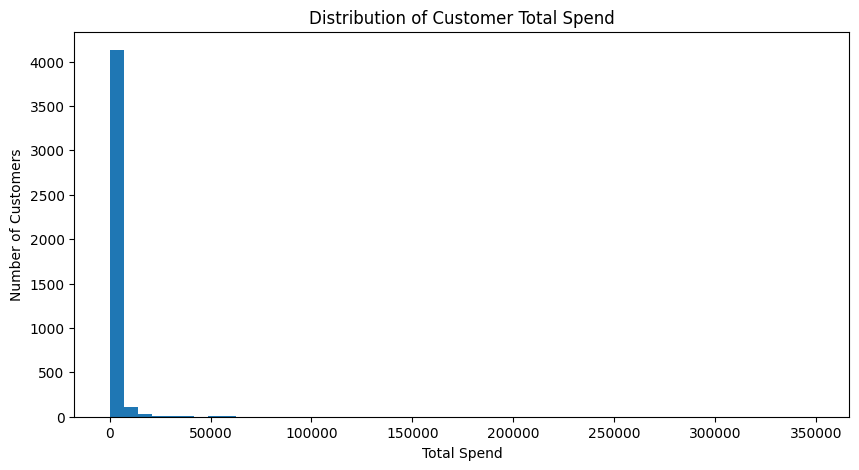

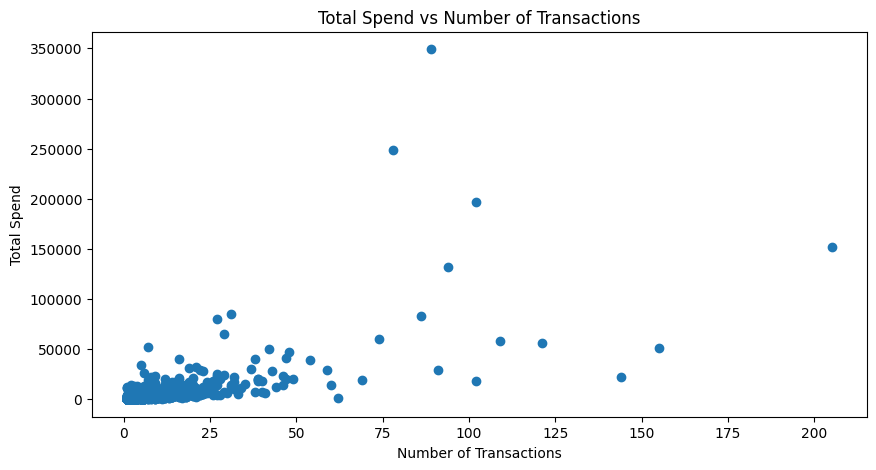

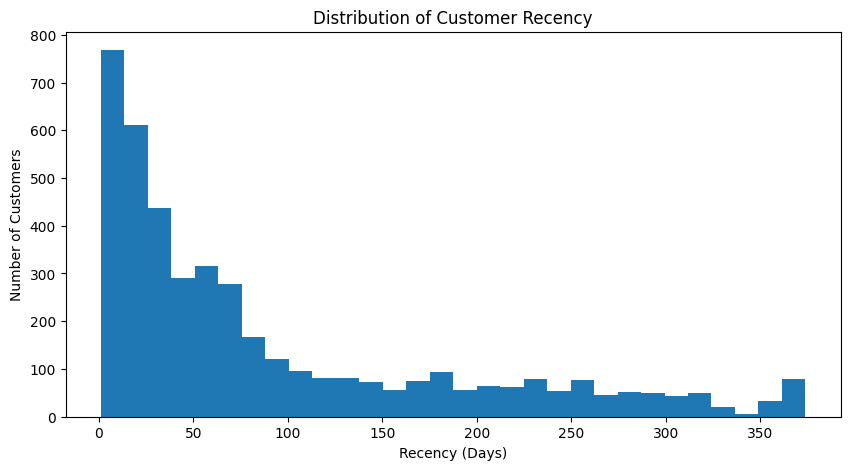

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
CustomerID,1.000000,-0.010369,-0.018842,-0.003574,-0.024128,-0.023654,0.001896
TotalSpend,-0.010369,1.000000,0.775738,0.655504,0.096339,0.025067,-0.120763
TotalQuantity,-0.018842,0.775738,1.000000,0.498078,0.090279,-0.006004,-0.084361
NumberOfTransactions,-0.003574,0.655504,0.498078,1.000000,0.015969,-0.010089,-0.248784
AverageOrderValue,-0.024128,0.096339,0.090279,0.015969,1.000000,0.931375,0.039449
AverageUnitPrice,-0.023654,0.025067,-0.006004,-0.010089,0.931375,1.000000,0.042611
RecencyDays,0.001896,-0.120763,-0.084361,-0.248784,0.039449,0.042611,1.000000


TotalSpend              1.000000
TotalQuantity           0.775738
NumberOfTransactions    0.655504
AverageOrderValue       0.096339
AverageUnitPrice        0.025067
CustomerID             -0.010369
RecencyDays            -0.120763
Name: TotalSpend, dtype: float64

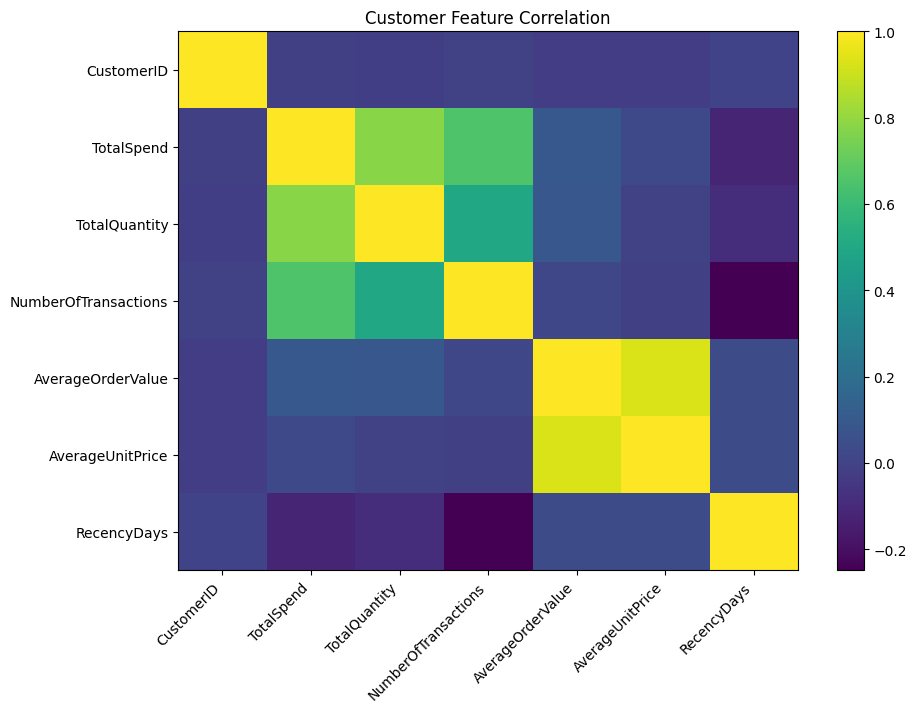

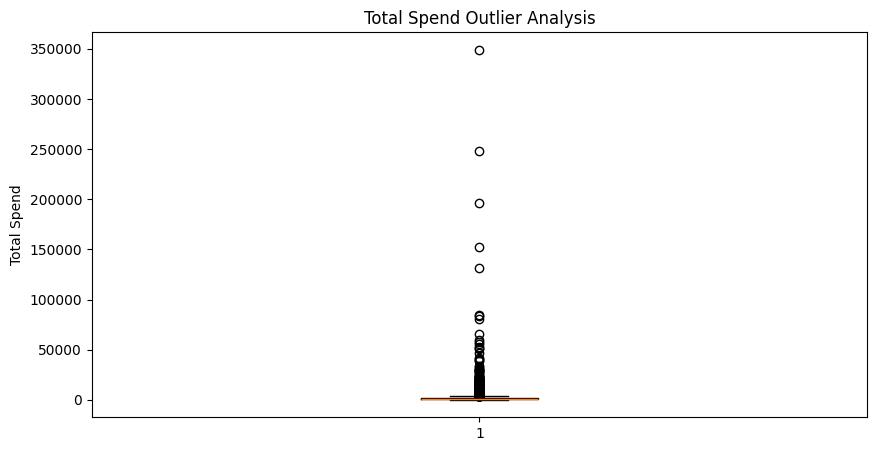

SpendSegment
Low       1438
Medium    1437
High      1437
Name: count, dtype: int64

,count,mean,median,min,max
SpendSegment,,,,,
Low,1438,219.598742,218.405,2.95,399.95
Medium,1437,743.070078,701.620,400.06,1266.77
High,1437,5159.818407,2485.460,1269.05,349164.35


(4312, 8)
['CustomerID', 'TotalSpend', 'TotalQuantity', 'NumberOfTransactions', 'AverageOrderValue', 'AverageUnitPrice', 'RecencyDays', 'SpendSegment']
EDA completed successfully!


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/cleaned_online_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

customer_df = df.groupby("CustomerID").agg(
    TotalSpend=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    AverageOrderValue=("TotalPrice", "mean"),
    AverageUnitPrice=("UnitPrice", "mean")
).reset_index()

latest_date = df["InvoiceDate"].max()
reference_date = latest_date + pd.Timedelta(days=1)

recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()

recency["RecencyDays"] = (
    reference_date - recency["InvoiceDate"]
).dt.days

customer_df = customer_df.merge(
    recency[["CustomerID", "RecencyDays"]],
    on="CustomerID",
    how="left"
)

print(customer_df.shape)
print(customer_df.columns.tolist())
print(customer_df.isnull().sum())

display(customer_df.describe())
display(customer_df.head())

top_spenders = customer_df.sort_values(
    "TotalSpend",
    ascending=False
).head(10)

display(top_spenders)

top_frequent = customer_df.sort_values(
    "NumberOfTransactions",
    ascending=False
).head(10)

display(top_frequent)

plt.figure(figsize=(10, 5))
plt.hist(customer_df["TotalSpend"], bins=50)
plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Total Spend")
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(
    customer_df["NumberOfTransactions"],
    customer_df["TotalSpend"]
)
plt.xlabel("Number of Transactions")
plt.ylabel("Total Spend")
plt.title("Total Spend vs Number of Transactions")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(customer_df["RecencyDays"], bins=30)
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Recency")
plt.show()

correlation = customer_df.corr(numeric_only=True)

display(correlation)
display(correlation["TotalSpend"].sort_values(ascending=False))

plt.figure(figsize=(10, 7))
plt.imshow(correlation, aspect="auto")
plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)
plt.colorbar()
plt.title("Customer Feature Correlation")
plt.show()

plt.figure(figsize=(10, 5))
plt.boxplot(customer_df["TotalSpend"])
plt.ylabel("Total Spend")
plt.title("Total Spend Outlier Analysis")
plt.show()

customer_df["SpendSegment"] = pd.qcut(
    customer_df["TotalSpend"],
    q=3,
    labels=["Low", "Medium", "High"]
)

display(customer_df["SpendSegment"].value_counts())

segment_analysis = customer_df.groupby(
    "SpendSegment",
    observed=True
)["TotalSpend"].agg(
    ["count", "mean", "median", "min", "max"]
)

display(segment_analysis)

customer_df.to_csv(
    "../data/processed/customer_features_eda.csv",
    index=False
)

print(customer_df.shape)
print(customer_df.columns.tolist())
print("EDA completed successfully!")

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

raw_path = "../data/raw/online_retail_09_10.csv"
cleaned_path = "../data/processed/cleaned_online_retail.csv"
customer_path = "../data/processed/customer_features.csv"

df = pd.read_csv(raw_path)

print("Original dataset shape:", df.shape)

df = df.dropna(subset=["CustomerID"])
df = df.dropna(subset=["Description"])
df = df.drop_duplicates()

df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df = df[~df["InvoiceNo"].str.startswith("C")]

df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

df["CustomerID"] = df["CustomerID"].astype(int)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Hour"] = df["InvoiceDate"].dt.hour

df.to_csv(cleaned_path, index=False)

latest_date = df["InvoiceDate"].max()
reference_date = latest_date + pd.Timedelta(days=1)

customer_df = df.groupby("CustomerID").agg(
    TotalSpend=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    AverageOrderValue=("TotalPrice", "mean"),
    AverageUnitPrice=("UnitPrice", "mean")
).reset_index()

recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()
recency["RecencyDays"] = (
    reference_date - recency["InvoiceDate"]
).dt.days

customer_df = customer_df.merge(
    recency[["CustomerID", "RecencyDays"]],
    on="CustomerID",
    how="left"
)

customer_df["SpendSegment"] = pd.qcut(
    customer_df["TotalSpend"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

print("Cleaned dataset shape:", df.shape)
print("Customer dataset shape:", customer_df.shape)
print("Number of customers:", customer_df["CustomerID"].nunique())

print("\nCustomer Features:")
print(customer_df.head())

print("\nMissing Values:")
print(customer_df.isnull().sum())

print("\nSpend Segment:")
print(customer_df["SpendSegment"].value_counts())

Q1 = customer_df["TotalSpend"].quantile(0.25)
Q3 = customer_df["TotalSpend"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = customer_df[
    (customer_df["TotalSpend"] < lower_limit) |
    (customer_df["TotalSpend"] > upper_limit)
]

print("\nNumber of TotalSpend outliers:", len(outliers))

correlation = customer_df.select_dtypes(include=np.number).corr()

print("\nCorrelation Matrix:")
print(correlation)

plt.figure(figsize=(10, 5))
plt.hist(customer_df["TotalSpend"], bins=50)
plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")
plt.title("Customer Total Spend Distribution")
plt.show()

plt.figure(figsize=(10, 5))
plt.boxplot(customer_df["TotalSpend"])
plt.ylabel("Total Spend")
plt.title("Total Spend Outlier Analysis")
plt.show()

plt.figure(figsize=(10, 7))
plt.imshow(correlation, aspect="auto")
plt.colorbar()
plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)
plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)
plt.title("Customer Feature Correlation")
plt.show()

segment_summary = customer_df.groupby(
    "SpendSegment",
    observed=True
)["TotalSpend"].agg(
    ["count", "mean", "median", "min", "max"]
)

print("\nSpend Segment Summary:")
print(segment_summary)

customer_df.to_csv(customer_path, index=False)

print("\nCustomer feature dataset saved successfully.")
print("Saved file:", customer_path)
print("\nAvailable columns:")
print(df.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/online_retail_09_10.csv'

Original dataset shape: (400916, 13)
Customer dataset shape: (4312, 7)

Customer columns:
['CustomerID', 'TotalSpend', 'TotalQuantity', 'NumberOfTransactions', 'AverageOrderValue', 'AverageUnitPrice', 'RecencyDays']

Missing values:
CustomerID              0
TotalSpend              0
TotalQuantity           0
NumberOfTransactions    0
AverageOrderValue       0
AverageUnitPrice        0
RecencyDays             0
dtype: int64

Customer statistics:


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
count,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,2040.406712,1280.050557,4.455705,37.009327,9.865097,91.171846
std,1701.200176,8911.755977,6457.926351,8.170213,217.715476,203.373443,96.860633
min,12346.000000,2.950000,1.000000,1.000000,1.993684,0.151333,1.000000
25%,13882.500000,307.187500,156.000000,1.000000,11.193531,2.302096,18.000000
50%,15350.500000,701.615000,380.000000,2.000000,17.361560,2.965765,53.000000
75%,16834.250000,1714.932500,992.000000,5.000000,24.839503,3.890407,136.000000
max,18287.000000,349164.350000,220600.000000,205.000000,10953.500000,10953.500000,374.000000



First 5 customers:


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
0,12346,372.86,70,11,11.298788,6.253333,165
1,12347,1323.32,828,2,18.638310,2.295070,3
2,12348,222.16,373,1,11.108000,0.719500,74
3,12349,2671.14,993,3,26.187647,8.581765,43
4,12351,300.93,261,1,14.330000,2.355238,11



Top 10 highest spending customers:


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
4183,18102,349164.35,124216,89,556.880941,3.491930,1
1637,14646,248396.50,170278,78,140.099549,2.402702,10
1269,14156,196549.74,108105,102,74.281837,7.059286,7
1840,14911,152121.22,69709,205,27.320621,5.668200,1
939,13694,131443.19,125893,94,137.349206,1.722497,9
3744,17511,84541.17,55107,31,89.178449,2.502247,3
1951,15061,83284.38,51791,86,142.610240,2.234966,3
3128,16684,80489.21,54555,27,182.515215,2.665011,15
3177,16754,65500.07,63551,29,467.857643,1.681929,8
4065,17949,60117.60,30112,74,691.006897,105.990115,7



Top 10 most frequent customers:


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
1840,14911,152121.22,69709,205,27.320621,5.668200,1
3996,17850,51208.87,21052,155,20.491745,3.063581,8
251,12748,22457.90,13109,144,8.873133,3.601881,1
2133,15311,55942.74,32784,121,27.449823,2.880849,1
506,13089,57885.45,29125,109,37.539202,2.656530,4
1606,14606,18482.10,9287,102,4.861152,2.852046,2
1269,14156,196549.74,108105,102,74.281837,7.059286,7
939,13694,131443.19,125893,94,137.349206,1.722497,9
3989,17841,29562.02,14332,91,5.979373,3.022502,1
4183,18102,349164.35,124216,89,556.880941,3.491930,1


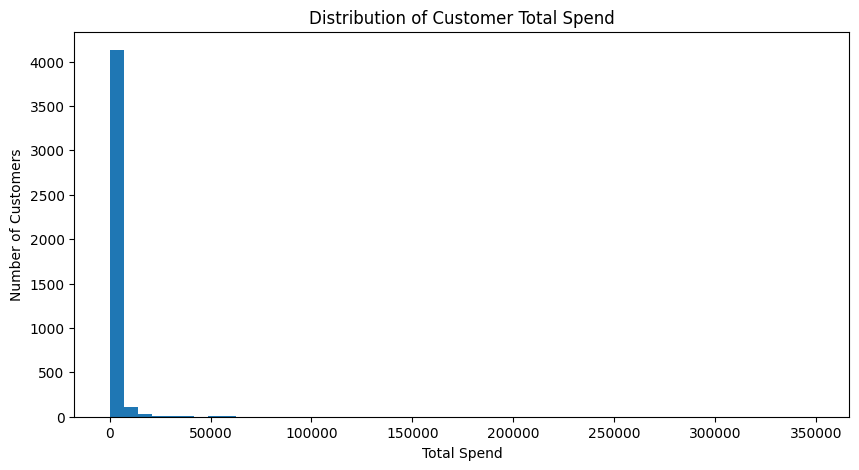

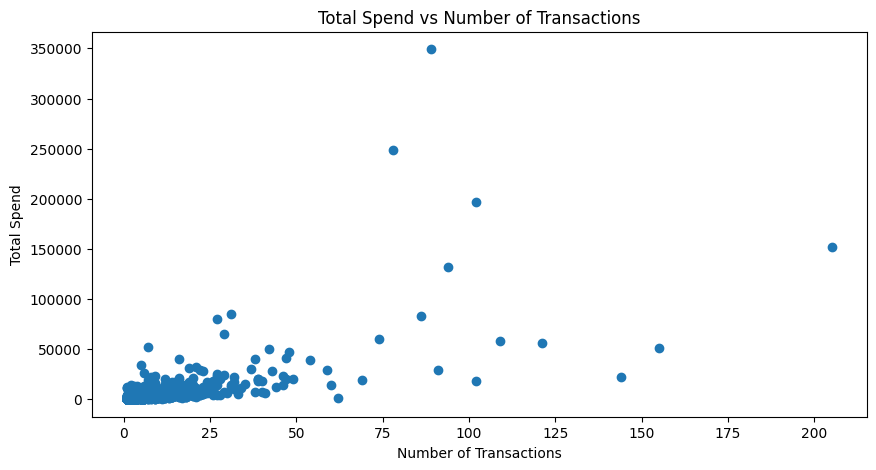

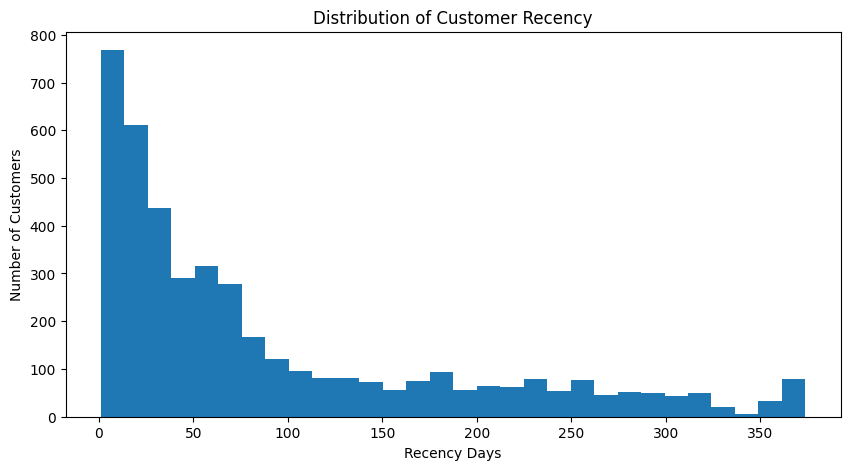


Correlation matrix:


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
CustomerID,1.000000,-0.010369,-0.018842,-0.003574,-0.024128,-0.023654,0.001896
TotalSpend,-0.010369,1.000000,0.775738,0.655504,0.096339,0.025067,-0.120763
TotalQuantity,-0.018842,0.775738,1.000000,0.498078,0.090279,-0.006004,-0.084361
NumberOfTransactions,-0.003574,0.655504,0.498078,1.000000,0.015969,-0.010089,-0.248784
AverageOrderValue,-0.024128,0.096339,0.090279,0.015969,1.000000,0.931375,0.039449
AverageUnitPrice,-0.023654,0.025067,-0.006004,-0.010089,0.931375,1.000000,0.042611
RecencyDays,0.001896,-0.120763,-0.084361,-0.248784,0.039449,0.042611,1.000000



Correlation with TotalSpend:


TotalSpend              1.000000
TotalQuantity           0.775738
NumberOfTransactions    0.655504
AverageOrderValue       0.096339
AverageUnitPrice        0.025067
CustomerID             -0.010369
RecencyDays            -0.120763
Name: TotalSpend, dtype: float64

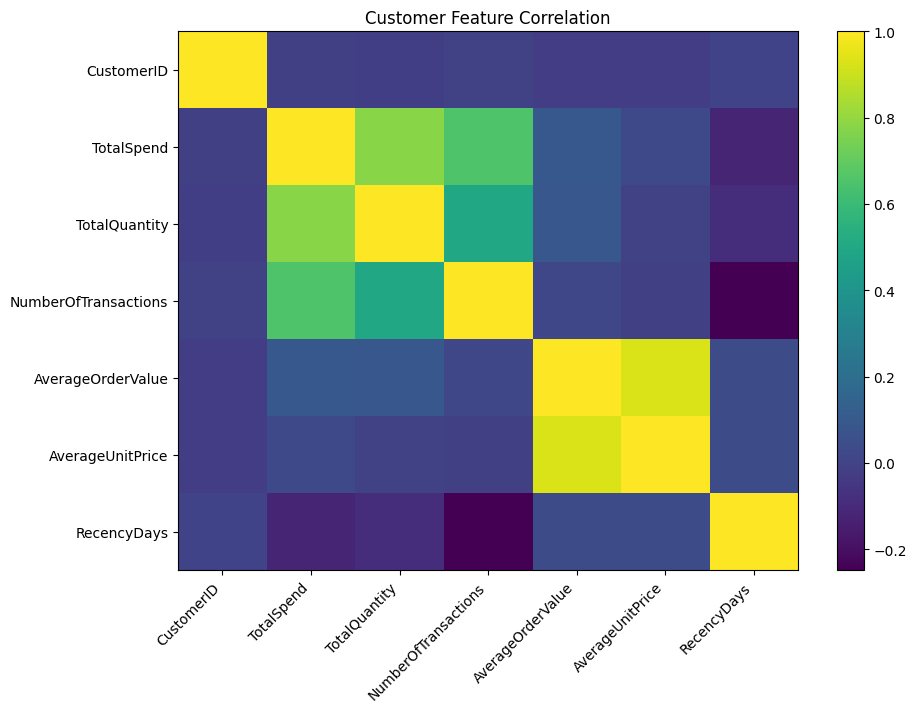

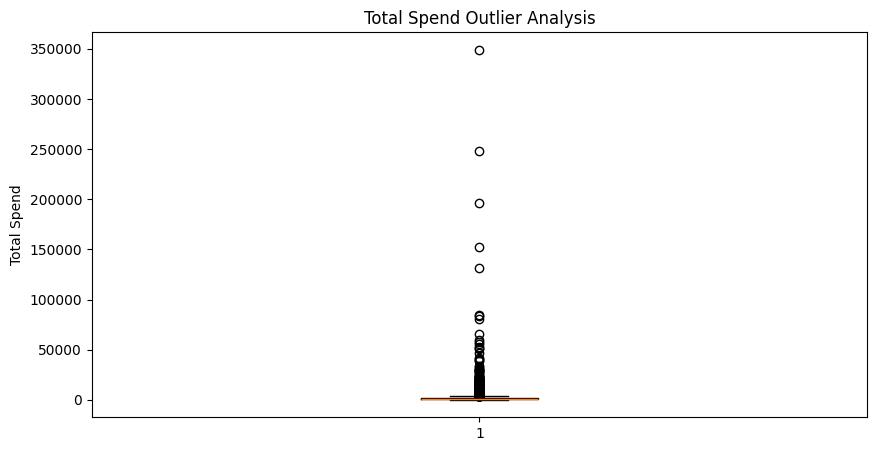


Number of TotalSpend outliers:
423

Top 10 highest spending customers:


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
4183,18102,349164.35,124216,89,556.880941,3.491930,1
1637,14646,248396.50,170278,78,140.099549,2.402702,10
1269,14156,196549.74,108105,102,74.281837,7.059286,7
1840,14911,152121.22,69709,205,27.320621,5.668200,1
939,13694,131443.19,125893,94,137.349206,1.722497,9
3744,17511,84541.17,55107,31,89.178449,2.502247,3
1951,15061,83284.38,51791,86,142.610240,2.234966,3
3128,16684,80489.21,54555,27,182.515215,2.665011,15
3177,16754,65500.07,63551,29,467.857643,1.681929,8
4065,17949,60117.60,30112,74,691.006897,105.990115,7



Customer segment counts:


SpendSegment
Low       1438
Medium    1437
High      1437
Name: count, dtype: int64


Customer segment analysis:


,CustomerCount,AverageSpend,MedianSpend,AverageQuantity,AverageTransactions,AverageOrderValue,AverageRecency
SpendSegment,,,,,,,
Low,1438,219.598742,218.405,133.457580,1.312935,22.634237,145.206537
Medium,1437,743.070078,701.620,439.100209,2.752958,28.046687,83.599861
High,1437,5159.818407,2485.460,3268.391788,9.303410,60.357059,44.671538


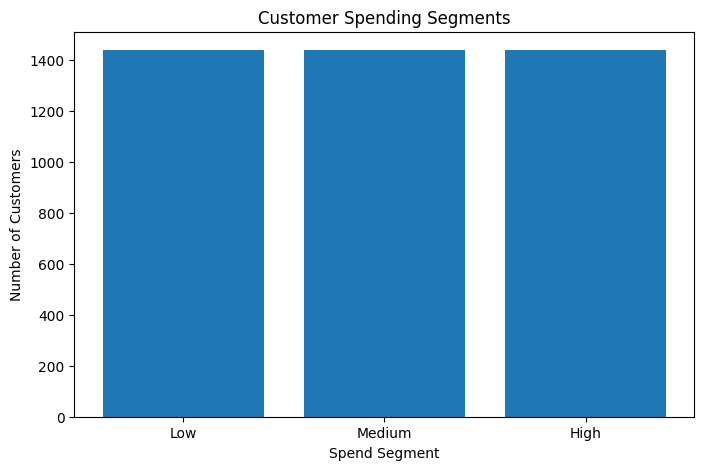

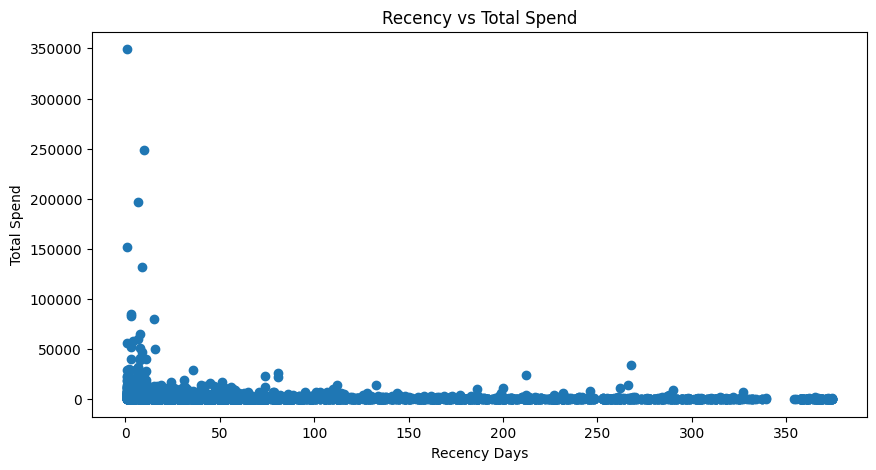

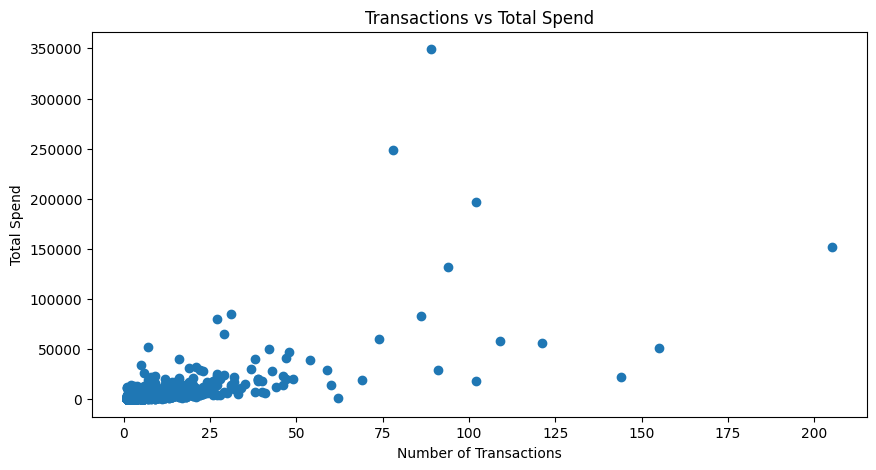


Final customer dataset shape:
(4312, 8)

Final columns:
['CustomerID', 'TotalSpend', 'TotalQuantity', 'NumberOfTransactions', 'AverageOrderValue', 'AverageUnitPrice', 'RecencyDays', 'SpendSegment']

EDA completed successfully!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/cleaned_online_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Original dataset shape:", df.shape)

customer_df = df.groupby("CustomerID").agg(
    TotalSpend=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    AverageOrderValue=("TotalPrice", "mean"),
    AverageUnitPrice=("UnitPrice", "mean")
).reset_index()

latest_date = df["InvoiceDate"].max()
reference_date = latest_date + pd.Timedelta(days=1)

recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()

recency["RecencyDays"] = (
    reference_date - recency["InvoiceDate"]
).dt.days

customer_df = customer_df.merge(
    recency[["CustomerID", "RecencyDays"]],
    on="CustomerID",
    how="left"
)

print("Customer dataset shape:", customer_df.shape)

print("\nCustomer columns:")
print(customer_df.columns.tolist())

print("\nMissing values:")
print(customer_df.isnull().sum())

print("\nCustomer statistics:")
display(customer_df.describe())

print("\nFirst 5 customers:")
display(customer_df.head())

top_spenders = customer_df.sort_values(
    "TotalSpend",
    ascending=False
).head(10)

print("\nTop 10 highest spending customers:")
display(top_spenders)

top_frequent = customer_df.sort_values(
    "NumberOfTransactions",
    ascending=False
).head(10)

print("\nTop 10 most frequent customers:")
display(top_frequent)

plt.figure(figsize=(10, 5))

plt.hist(
    customer_df["TotalSpend"],
    bins=50
)

plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Total Spend")

plt.show()

plt.figure(figsize=(10, 5))

plt.scatter(
    customer_df["NumberOfTransactions"],
    customer_df["TotalSpend"]
)

plt.xlabel("Number of Transactions")
plt.ylabel("Total Spend")
plt.title("Total Spend vs Number of Transactions")

plt.show()

plt.figure(figsize=(10, 5))

plt.hist(
    customer_df["RecencyDays"],
    bins=30
)

plt.xlabel("Recency Days")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Recency")

plt.show()

correlation = customer_df.corr(
    numeric_only=True
)

print("\nCorrelation matrix:")
display(correlation)

print("\nCorrelation with TotalSpend:")
display(
    correlation["TotalSpend"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 7))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.colorbar()

plt.title("Customer Feature Correlation")

plt.show()

plt.figure(figsize=(10, 5))

plt.boxplot(
    customer_df["TotalSpend"]
)

plt.ylabel("Total Spend")
plt.title("Total Spend Outlier Analysis")

plt.show()

Q1 = customer_df["TotalSpend"].quantile(0.25)
Q3 = customer_df["TotalSpend"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = customer_df[
    (customer_df["TotalSpend"] < lower_limit) |
    (customer_df["TotalSpend"] > upper_limit)
]

print("\nNumber of TotalSpend outliers:")
print(len(outliers))

print("\nTop 10 highest spending customers:")
display(
    customer_df.sort_values(
        "TotalSpend",
        ascending=False
    ).head(10)
)

customer_df["SpendSegment"] = pd.qcut(
    customer_df["TotalSpend"],
    q=3,
    labels=["Low", "Medium", "High"]
)

print("\nCustomer segment counts:")
display(
    customer_df["SpendSegment"].value_counts()
)

segment_analysis = customer_df.groupby(
    "SpendSegment",
    observed=True
).agg(
    CustomerCount=("CustomerID", "count"),
    AverageSpend=("TotalSpend", "mean"),
    MedianSpend=("TotalSpend", "median"),
    AverageQuantity=("TotalQuantity", "mean"),
    AverageTransactions=("NumberOfTransactions", "mean"),
    AverageOrderValue=("AverageOrderValue", "mean"),
    AverageRecency=("RecencyDays", "mean")
)

print("\nCustomer segment analysis:")
display(segment_analysis)

plt.figure(figsize=(8, 5))

segment_counts = (
    customer_df["SpendSegment"]
    .value_counts()
    .sort_index()
)

plt.bar(
    segment_counts.index.astype(str),
    segment_counts.values
)

plt.xlabel("Spend Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Spending Segments")

plt.show()

plt.figure(figsize=(10, 5))

plt.scatter(
    customer_df["RecencyDays"],
    customer_df["TotalSpend"]
)

plt.xlabel("Recency Days")
plt.ylabel("Total Spend")
plt.title("Recency vs Total Spend")

plt.show()

plt.figure(figsize=(10, 5))

plt.scatter(
    customer_df["NumberOfTransactions"],
    customer_df["TotalSpend"]
)

plt.xlabel("Number of Transactions")
plt.ylabel("Total Spend")
plt.title("Transactions vs Total Spend")

plt.show()

customer_df.to_csv(
    "../data/processed/customer_features_eda.csv",
    index=False
)

print("\nFinal customer dataset shape:")
print(customer_df.shape)

print("\nFinal columns:")
print(customer_df.columns.tolist())

print("\nEDA completed successfully!")

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/cleaned_online_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Dataset shape:", df.shape)
print("\nDataset columns:")
print(df.columns.tolist())

customer_df = df.groupby("CustomerID").agg(
    TotalSpend=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    AverageOrderValue=("TotalPrice", "mean"),
    AverageUnitPrice=("UnitPrice", "mean")
).reset_index()

latest_date = df["InvoiceDate"].max()
reference_date = latest_date + pd.Timedelta(days=1)

recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()

recency["RecencyDays"] = (
    reference_date - recency["InvoiceDate"]
).dt.days

customer_df = customer_df.merge(
    recency[["CustomerID", "RecencyDays"]],
    on="CustomerID",
    how="left"
)

customer_df["SpendSegment"] = pd.qcut(
    customer_df["TotalSpend"],
    q=3,
    labels=["Low", "Medium", "High"]
)

customer_df = customer_df.dropna()

print("\nCustomer dataset shape:", customer_df.shape)

print("\nCustomer features:")
print(customer_df.columns.tolist())

print("\nMissing values:")
print(customer_df.isnull().sum())

print("\nCustomer feature statistics:")
display(customer_df.describe())

print("\nCustomer segment distribution:")
display(customer_df["SpendSegment"].value_counts())

segment_analysis = customer_df.groupby(
    "SpendSegment",
    observed=True
).agg(
    CustomerCount=("CustomerID", "count"),
    AverageSpend=("TotalSpend", "mean"),
    AverageQuantity=("TotalQuantity", "mean"),
    AverageTransactions=("NumberOfTransactions", "mean"),
    AverageOrderValue=("AverageOrderValue", "mean"),
    AverageRecency=("RecencyDays", "mean")
)

print("\nSegment analysis:")
display(segment_analysis)

customer_df.to_csv(
    "../data/processed/customer_causal_features.csv",
    index=False
)

print("\nSaved file:")
print("../data/processed/customer_causal_features.csv")

print("\nToday's customer feature preparation completed successfully!")

Dataset shape: (400916, 13)

Dataset columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Year', 'Month', 'Day', 'Hour']

Customer dataset shape: (4312, 8)

Customer features:
['CustomerID', 'TotalSpend', 'TotalQuantity', 'NumberOfTransactions', 'AverageOrderValue', 'AverageUnitPrice', 'RecencyDays', 'SpendSegment']

Missing values:
CustomerID              0
TotalSpend              0
TotalQuantity           0
NumberOfTransactions    0
AverageOrderValue       0
AverageUnitPrice        0
RecencyDays             0
SpendSegment            0
dtype: int64

Customer feature statistics:


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
count,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,2040.406712,1280.050557,4.455705,37.009327,9.865097,91.171846
std,1701.200176,8911.755977,6457.926351,8.170213,217.715476,203.373443,96.860633
min,12346.000000,2.950000,1.000000,1.000000,1.993684,0.151333,1.000000
25%,13882.500000,307.187500,156.000000,1.000000,11.193531,2.302096,18.000000
50%,15350.500000,701.615000,380.000000,2.000000,17.361560,2.965765,53.000000
75%,16834.250000,1714.932500,992.000000,5.000000,24.839503,3.890407,136.000000
max,18287.000000,349164.350000,220600.000000,205.000000,10953.500000,10953.500000,374.000000



Customer segment distribution:


SpendSegment
Low       1438
Medium    1437
High      1437
Name: count, dtype: int64


Segment analysis:


,CustomerCount,AverageSpend,AverageQuantity,AverageTransactions,AverageOrderValue,AverageRecency
SpendSegment,,,,,,
Low,1438,219.598742,133.457580,1.312935,22.634237,145.206537
Medium,1437,743.070078,439.100209,2.752958,28.046687,83.599861
High,1437,5159.818407,3268.391788,9.303410,60.357059,44.671538



Saved file:
../data/processed/customer_causal_features.csv

Today's customer feature preparation completed successfully!


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/cleaned_online_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Dataset shape:", df.shape)
print("\nDataset columns:")
print(df.columns.tolist())

customer_df = df.groupby("CustomerID").agg(
    TotalSpend=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    AverageOrderValue=("TotalPrice", "mean"),
    AverageUnitPrice=("UnitPrice", "mean")
).reset_index()

latest_date = df["InvoiceDate"].max()
reference_date = latest_date + pd.Timedelta(days=1)

recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()

recency["RecencyDays"] = (
    reference_date - recency["InvoiceDate"]
).dt.days

customer_df = customer_df.merge(
    recency[["CustomerID", "RecencyDays"]],
    on="CustomerID",
    how="left"
)

customer_df["SpendSegment"] = pd.qcut(
    customer_df["TotalSpend"],
    q=3,
    labels=["Low", "Medium", "High"]
)

customer_df = customer_df.dropna()

print("\nCustomer dataset shape:", customer_df.shape)

print("\nCustomer features:")
print(customer_df.columns.tolist())

print("\nMissing values:")
print(customer_df.isnull().sum())

print("\nCustomer feature statistics:")
display(customer_df.describe())

print("\nCustomer segment distribution:")
display(customer_df["SpendSegment"].value_counts())

segment_analysis = customer_df.groupby(
    "SpendSegment",
    observed=True
).agg(
    CustomerCount=("CustomerID", "count"),
    AverageSpend=("TotalSpend", "mean"),
    AverageQuantity=("TotalQuantity", "mean"),
    AverageTransactions=("NumberOfTransactions", "mean"),
    AverageOrderValue=("AverageOrderValue", "mean"),
    AverageRecency=("RecencyDays", "mean")
)

print("\nSegment analysis:")
display(segment_analysis)

customer_df.to_csv(
    "../data/processed/customer_causal_features.csv",
    index=False
)

print("\nSaved file:")
print("../data/processed/customer_causal_features.csv")

print("\nToday's customer feature preparation completed successfully!")

Dataset shape: (400916, 13)

Dataset columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Year', 'Month', 'Day', 'Hour']

Customer dataset shape: (4312, 8)

Customer features:
['CustomerID', 'TotalSpend', 'TotalQuantity', 'NumberOfTransactions', 'AverageOrderValue', 'AverageUnitPrice', 'RecencyDays', 'SpendSegment']

Missing values:
CustomerID              0
TotalSpend              0
TotalQuantity           0
NumberOfTransactions    0
AverageOrderValue       0
AverageUnitPrice        0
RecencyDays             0
SpendSegment            0
dtype: int64

Customer feature statistics:


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
count,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,2040.406712,1280.050557,4.455705,37.009327,9.865097,91.171846
std,1701.200176,8911.755977,6457.926351,8.170213,217.715476,203.373443,96.860633
min,12346.000000,2.950000,1.000000,1.000000,1.993684,0.151333,1.000000
25%,13882.500000,307.187500,156.000000,1.000000,11.193531,2.302096,18.000000
50%,15350.500000,701.615000,380.000000,2.000000,17.361560,2.965765,53.000000
75%,16834.250000,1714.932500,992.000000,5.000000,24.839503,3.890407,136.000000
max,18287.000000,349164.350000,220600.000000,205.000000,10953.500000,10953.500000,374.000000



Customer segment distribution:


SpendSegment
Low       1438
Medium    1437
High      1437
Name: count, dtype: int64


Segment analysis:


,CustomerCount,AverageSpend,AverageQuantity,AverageTransactions,AverageOrderValue,AverageRecency
SpendSegment,,,,,,
Low,1438,219.598742,133.457580,1.312935,22.634237,145.206537
Medium,1437,743.070078,439.100209,2.752958,28.046687,83.599861
High,1437,5159.818407,3268.391788,9.303410,60.357059,44.671538



Saved file:
../data/processed/customer_causal_features.csv

Today's customer feature preparation completed successfully!


In [ ]:
latest_date = df["InvoiceDate"].max()
reference_date = latest_date + pd.Timedelta(days=1)

recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()
recency["RecencyDays"] = (reference_date - recency["InvoiceDate"]).dt.days
recency = recency[["CustomerID", "RecencyDays"]]

customer_df = customer_df.merge(
    recency,
    on="CustomerID",
    how="left"
)

customer_df.head()

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays_x,SpendSegment,RecencyDays_y
0,12346,372.86,70,11,11.298788,6.253333,165,Low,165
1,12347,1323.32,828,2,18.638310,2.295070,3,High,3
2,12348,222.16,373,1,11.108000,0.719500,74,Low,74
3,12349,2671.14,993,3,26.187647,8.581765,43,High,43
4,12351,300.93,261,1,14.330000,2.355238,11,Low,11


In [ ]:
customer_df.shape

(4312, 9)

In [ ]:
customer_df.columns.tolist()

['CustomerID',
 'TotalSpend',
 'TotalQuantity',
 'NumberOfTransactions',
 'AverageOrderValue',
 'AverageUnitPrice',
 'RecencyDays_x',
 'SpendSegment',
 'RecencyDays_y']

In [ ]:
customer_df.isnull().sum()

CustomerID              0
TotalSpend              0
TotalQuantity           0
NumberOfTransactions    0
AverageOrderValue       0
AverageUnitPrice        0
RecencyDays_x           0
SpendSegment            0
RecencyDays_y           0
dtype: int64

In [ ]:
customer_df.describe()

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays_x,RecencyDays_y
count,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,2040.406712,1280.050557,4.455705,37.009327,9.865097,91.171846,91.171846
std,1701.200176,8911.755977,6457.926351,8.170213,217.715476,203.373443,96.860633,96.860633
min,12346.000000,2.950000,1.000000,1.000000,1.993684,0.151333,1.000000,1.000000
25%,13882.500000,307.187500,156.000000,1.000000,11.193531,2.302096,18.000000,18.000000
50%,15350.500000,701.615000,380.000000,2.000000,17.361560,2.965765,53.000000,53.000000
75%,16834.250000,1714.932500,992.000000,5.000000,24.839503,3.890407,136.000000,136.000000
max,18287.000000,349164.350000,220600.000000,205.000000,10953.500000,10953.500000,374.000000,374.000000


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/cleaned_online_retail.csv")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [ ]:
customer_df = df.groupby("CustomerID").agg(
    TotalSpend=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    AverageOrderValue=("TotalPrice", "mean"),
    AverageUnitPrice=("UnitPrice", "mean")
).reset_index()

In [ ]:
latest_date = df["InvoiceDate"].max()
reference_date = latest_date + pd.Timedelta(days=1)

recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()
recency["RecencyDays"] = (
    reference_date - recency["InvoiceDate"]
).dt.days

customer_df = customer_df.merge(
    recency[["CustomerID", "RecencyDays"]],
    on="CustomerID",
    how="left"
)

customer_df.head()

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
0,12346,372.86,70,11,11.298788,6.253333,165
1,12347,1323.32,828,2,18.638310,2.295070,3
2,12348,222.16,373,1,11.108000,0.719500,74
3,12349,2671.14,993,3,26.187647,8.581765,43
4,12351,300.93,261,1,14.330000,2.355238,11


In [ ]:
customer_df.shape

(4312, 7)

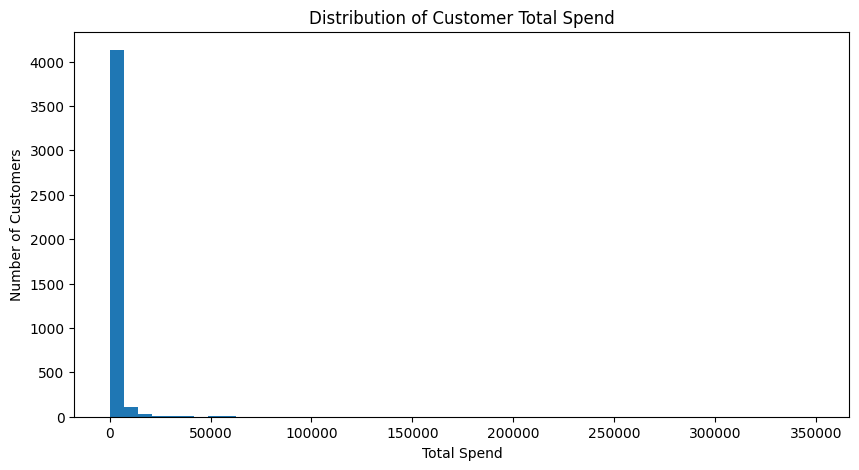

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(customer_df["TotalSpend"], bins=50)
plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Total Spend")
plt.show()

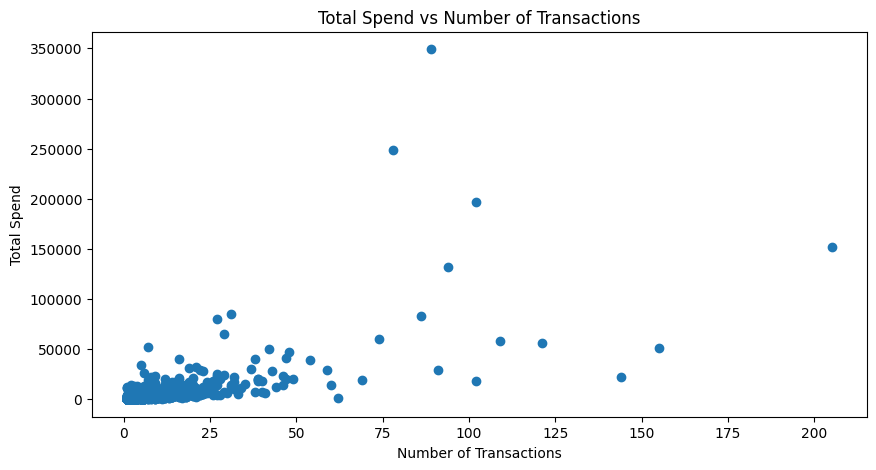

In [ ]:
plt.figure(figsize=(10, 5))

plt.scatter(
    customer_df["NumberOfTransactions"],
    customer_df["TotalSpend"]
)

plt.xlabel("Number of Transactions")
plt.ylabel("Total Spend")
plt.title("Total Spend vs Number of Transactions")

plt.show()

In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

latest_date = df["InvoiceDate"].max()
reference_date = latest_date + pd.Timedelta(days=1)

recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()

recency["RecencyDays"] = (
    reference_date - recency["InvoiceDate"]
).dt.days

customer_df = customer_df.merge(
    recency[["CustomerID", "RecencyDays"]],
    on="CustomerID",
    how="left"
)

customer_df.head()

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays_x,RecencyDays_y
0,12346,372.86,70,11,11.298788,6.253333,165,165
1,12347,1323.32,828,2,18.638310,2.295070,3,3
2,12348,222.16,373,1,11.108000,0.719500,74,74
3,12349,2671.14,993,3,26.187647,8.581765,43,43
4,12351,300.93,261,1,14.330000,2.355238,11,11


In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

customer_df = df.groupby("CustomerID").agg(
    TotalSpend=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    AverageOrderValue=("TotalPrice", "mean"),
    AverageUnitPrice=("UnitPrice", "mean")
).reset_index()

latest_date = df["InvoiceDate"].max()
reference_date = latest_date + pd.Timedelta(days=1)

recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()
recency["RecencyDays"] = (
    reference_date - recency["InvoiceDate"]
).dt.days

customer_df = customer_df.merge(
    recency[["CustomerID", "RecencyDays"]],
    on="CustomerID",
    how="left"
)

customer_df.head()

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
0,12346,372.86,70,11,11.298788,6.253333,165
1,12347,1323.32,828,2,18.638310,2.295070,3
2,12348,222.16,373,1,11.108000,0.719500,74
3,12349,2671.14,993,3,26.187647,8.581765,43
4,12351,300.93,261,1,14.330000,2.355238,11


In [ ]:
df = pd.read_csv("../data/processed/cleaned_online_retail.csv")

print("Rows:", len(df))
print("Columns:", df.shape[1])

Rows: 400916
Columns: 13


In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,1,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,1,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,1,7


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/cleaned_online_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

customer_df = df.groupby("CustomerID").agg(
    TotalSpend=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    AverageOrderValue=("TotalPrice", "mean"),
    AverageUnitPrice=("UnitPrice", "mean")
).reset_index()

latest_date = df["InvoiceDate"].max()
reference_date = latest_date + pd.Timedelta(days=1)

recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()

recency["RecencyDays"] = (
    reference_date - recency["InvoiceDate"]
).dt.days

customer_df = customer_df.merge(
    recency[["CustomerID", "RecencyDays"]],
    on="CustomerID",
    how="left"
)

print("Dataset shape:", customer_df.shape)
print("\nColumns:")
print(customer_df.columns.tolist())

print("\nMissing values:")
print(customer_df.isnull().sum())

print("\nStatistical summary:")
display(customer_df.describe())

customer_df.head()

Dataset shape: (4312, 7)

Columns:
['CustomerID', 'TotalSpend', 'TotalQuantity', 'NumberOfTransactions', 'AverageOrderValue', 'AverageUnitPrice', 'RecencyDays']

Missing values:
CustomerID              0
TotalSpend              0
TotalQuantity           0
NumberOfTransactions    0
AverageOrderValue       0
AverageUnitPrice        0
RecencyDays             0
dtype: int64

Statistical summary:


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
count,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,2040.406712,1280.050557,4.455705,37.009327,9.865097,91.171846
std,1701.200176,8911.755977,6457.926351,8.170213,217.715476,203.373443,96.860633
min,12346.000000,2.950000,1.000000,1.000000,1.993684,0.151333,1.000000
25%,13882.500000,307.187500,156.000000,1.000000,11.193531,2.302096,18.000000
50%,15350.500000,701.615000,380.000000,2.000000,17.361560,2.965765,53.000000
75%,16834.250000,1714.932500,992.000000,5.000000,24.839503,3.890407,136.000000
max,18287.000000,349164.350000,220600.000000,205.000000,10953.500000,10953.500000,374.000000


,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
0,12346,372.86,70,11,11.298788,6.253333,165
1,12347,1323.32,828,2,18.638310,2.295070,3
2,12348,222.16,373,1,11.108000,0.719500,74
3,12349,2671.14,993,3,26.187647,8.581765,43
4,12351,300.93,261,1,14.330000,2.355238,11


In [ ]:
customer_df.sort_values(
    "TotalSpend",
    ascending=False
).head(10)

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
4183,18102,349164.35,124216,89,556.880941,3.491930,1
1637,14646,248396.50,170278,78,140.099549,2.402702,10
1269,14156,196549.74,108105,102,74.281837,7.059286,7
1840,14911,152121.22,69709,205,27.320621,5.668200,1
939,13694,131443.19,125893,94,137.349206,1.722497,9
3744,17511,84541.17,55107,31,89.178449,2.502247,3
1951,15061,83284.38,51791,86,142.610240,2.234966,3
3128,16684,80489.21,54555,27,182.515215,2.665011,15
3177,16754,65500.07,63551,29,467.857643,1.681929,8
4065,17949,60117.60,30112,74,691.006897,105.990115,7


In [ ]:
correlation = customer_df.corr(numeric_only=True)

correlation

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
CustomerID,1.000000,-0.010369,-0.018842,-0.003574,-0.024128,-0.023654,0.001896
TotalSpend,-0.010369,1.000000,0.775738,0.655504,0.096339,0.025067,-0.120763
TotalQuantity,-0.018842,0.775738,1.000000,0.498078,0.090279,-0.006004,-0.084361
NumberOfTransactions,-0.003574,0.655504,0.498078,1.000000,0.015969,-0.010089,-0.248784
AverageOrderValue,-0.024128,0.096339,0.090279,0.015969,1.000000,0.931375,0.039449
AverageUnitPrice,-0.023654,0.025067,-0.006004,-0.010089,0.931375,1.000000,0.042611
RecencyDays,0.001896,-0.120763,-0.084361,-0.248784,0.039449,0.042611,1.000000


In [ ]:
correlation["TotalSpend"].sort_values(ascending=False)

TotalSpend              1.000000
TotalQuantity           0.775738
NumberOfTransactions    0.655504
AverageOrderValue       0.096339
AverageUnitPrice        0.025067
CustomerID             -0.010369
RecencyDays            -0.120763
Name: TotalSpend, dtype: float64

In [ ]:
print(df.columns.tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Year', 'Month', 'Day', 'Hour']


In [ ]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400916 entries, 0 to 400915
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    400916 non-null  int64         
 1   StockCode    400916 non-null  object        
 2   Description  400916 non-null  object        
 3   Quantity     400916 non-null  int64         
 4   InvoiceDate  400916 non-null  datetime64[ns]
 5   UnitPrice    400916 non-null  float64       
 6   CustomerID   400916 non-null  int64         
 7   Country      400916 non-null  object        
 8   TotalPrice   400916 non-null  float64       
 9   Year         400916 non-null  int64         
 10  Month        400916 non-null  int64         
 11  Day          400916 non-null  int64         
 12  Hour         400916 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(7), object(3)
memory usage: 39.8+ MB


,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice,Year,Month,Day,Hour
count,400916.000000,400916.000000,400916,400916.000000,400916.000000,400916.000000,400916.000000,400916.000000,400916.000000,400916.000000
mean,514731.380771,13.767418,2010-07-01 05:01:16.167027712,3.305826,15361.544074,21.945330,2009.924493,7.398166,15.365368,12.865191
min,489434.000000,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000,2009.000000,1.000000,1.000000,7.000000
25%,502752.000000,2.000000,2010-03-26 13:28:00,1.250000,13985.000000,5.000000,2010.000000,4.000000,8.000000,11.000000
50%,515192.000000,5.000000,2010-07-09 10:26:00,1.950000,15311.000000,12.500000,2010.000000,8.000000,15.000000,13.000000
75%,527065.500000,12.000000,2010-10-14 13:58:45,3.750000,16805.000000,19.500000,2010.000000,11.000000,23.000000,14.000000
max,538171.000000,19152.000000,2010-12-09 20:01:00,10953.500000,18287.000000,15818.400000,2010.000000,12.000000,31.000000,20.000000
std,14090.603233,97.638385,NaN,35.047719,1680.635823,77.758075,0.264208,3.472188,8.735086,2.306906


In [ ]:
customer_df = df.groupby("CustomerID").agg(
    TotalSpend=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    AverageOrderValue=("TotalPrice", "mean"),
    AverageUnitPrice=("UnitPrice", "mean")
).reset_index()

customer_df.head()

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice
0,12346,372.86,70,11,11.298788,6.253333
1,12347,1323.32,828,2,18.638310,2.295070
2,12348,222.16,373,1,11.108000,0.719500
3,12349,2671.14,993,3,26.187647,8.581765
4,12351,300.93,261,1,14.330000,2.355238


In [ ]:
print("Original transaction data:", df.shape)
print("Customer-level data:", customer_df.shape)

Original transaction data: (400916, 13)
Customer-level data: (4312, 6)


In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

latest_date = df["InvoiceDate"].max()
reference_date = latest_date + pd.Timedelta(days=1)

recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()
recency["RecencyDays"] = (reference_date - recency["InvoiceDate"]).dt.days
recency = recency[["CustomerID", "RecencyDays"]]

customer_df = customer_df.merge(recency, on="CustomerID", how="left")

customer_df.head()

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice,RecencyDays
0,12346,372.86,70,11,11.298788,6.253333,165
1,12347,1323.32,828,2,18.638310,2.295070,3
2,12348,222.16,373,1,11.108000,0.719500,74
3,12349,2671.14,993,3,26.187647,8.581765,43
4,12351,300.93,261,1,14.330000,2.355238,11


In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [ ]:
customer_df.shape

(4312, 7)

In [ ]:
customer_df.columns.tolist()

['CustomerID',
 'TotalSpend',
 'TotalQuantity',
 'NumberOfTransactions',
 'AverageOrderValue',
 'AverageUnitPrice',
 'RecencyDays']

In [ ]:
customer_df.isnull().sum()

CustomerID              0
TotalSpend              0
TotalQuantity           0
NumberOfTransactions    0
AverageOrderValue       0
AverageUnitPrice        0
RecencyDays             0
dtype: int64

In [ ]:
customer_df = df.groupby("CustomerID").agg(
    TotalSpend=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfTransactions=("InvoiceNo", "nunique"),
    AverageOrderValue=("TotalPrice", "mean"),
    AverageUnitPrice=("UnitPrice", "mean")
).reset_index()

customer_df.head()

,CustomerID,TotalSpend,TotalQuantity,NumberOfTransactions,AverageOrderValue,AverageUnitPrice
0,12346,372.86,70,11,11.298788,6.253333
1,12347,1323.32,828,2,18.638310,2.295070
2,12348,222.16,373,1,11.108000,0.719500
3,12349,2671.14,993,3,26.187647,8.581765
4,12351,300.93,261,1,14.330000,2.355238
